# Анализ базы данных колл-центра банка

Звонки за август 2022 года: 89 174 звонка, 1 962 оператора, 45 управлений, 4 продукта. Ниже — решения трёх заданий; в конце ноутбук собирает Excel-дашборд `db_analysys.xlsx`.

## Главное

* **Продажная конверсия — 15,2%** (3 310 продаж из 21 769 звонков с результатом «Успешно» или «Отказ»), дозвон — 43,3%, продуктом начинают пользоваться 61% купивших.
* **Главная зона роста — управления.** Различия между ними настоящие, а не случайные: Хирс и группа 17 Керса продают в 65–69% случаев, а 24 управления (от 100 звонков с результатом) — ниже средней. Если они выйдут на среднюю конверсию, это около +640 продаж в месяц (+19%).
* **Вечером и в выходные конверсия выше** (до 25–27% против 15%), но за счёт того, кто в это время работает: у одного и того же оператора разница незначима. Переносить звонки на вечер не стоит — стоит изучить, чем отличаются эти операторы.
* **Продукт 2 продаётся хуже остальных:** с учётом управления и времени шансы его продать на 38% ниже, чем продукт 1.
* **Не влияют на результат:** длительность звонка, источник задачи и знак зодиака оператора (кроме необъяснимо низкой конверсии «Тельцов»); доля начавших пользоваться продуктом не зависит от дня продажи.

## Что проверить в данных

* 58 «успешных» звонков нулевой длительности — все у двух операторов, которые возглавляют рейтинги конверсии (cyanrser и yrovibna);
* у управления Вирс все 251 звонок закончились «Недозвоном»;
* у задач из источника CM не заполнен этап, у 377 задач на промежуточных этапах нет даты окончания, 556 задач длятся дольше 62 дней;
* по справочнику знаков зодиака 40% операторов — «Девы»: похоже на значения по умолчанию.

## Загрузка и подключение к базе данных

In [1]:
from pathlib import Path
import sqlite3
import urllib.request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import ttest_ind, mannwhitneyu, levene, chi2_contingency
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.discrete.conditional_models import ConditionalLogit
from statsmodels.stats.proportion import proportion_confint
from statsmodels.stats.anova import anova_lm

pd.set_option('display.min_rows', 20)

DB_PATH = Path('data.db')
DB_URL = 'https://drive.google.com/uc?id=1pmfc0FrkMvlM2SITpFz6bilk-dvDG_y0&export=download'
DASHBOARD_PATH = Path('db_analysys.xlsx')  # Excel-дашборд, который собирается в конце ноутбука

# Базу скачиваем, только если её ещё нет рядом с ноутбуком
if not DB_PATH.exists():
    urllib.request.urlretrieve(DB_URL, DB_PATH)
    with open(DB_PATH, 'rb') as f:
        is_sqlite = f.read(16) == b'SQLite format 3\x00'
    if not is_sqlite:
        DB_PATH.unlink()
        raise RuntimeError(f'Не удалось скачать базу. Скачайте её вручную: {DB_URL} и сохраните как {DB_PATH}')

In [2]:
# База открывается только на чтение. Промежуточные таблицы создаются как TEMP и живут до конца сессии,
# поэтому data.db не меняется, а ноутбук можно перезапускать с начала сколько угодно раз
conn = sqlite3.connect(f'file:{DB_PATH}?mode=ro', uri=True)


def q(sql):
    """Выполняет SELECT и возвращает DataFrame."""
    return pd.read_sql_query(sql, conn)


def create_temp(name, sql):
    """Пересоздаёт временную таблицу name из запроса sql."""
    conn.execute(f'DROP TABLE IF EXISTS temp.{name}')
    conn.execute(f'CREATE TEMP TABLE {name} AS {sql}')


def add_wilson_ci(df, successes, total):
    """Добавляет 95% доверительный интервал Уилсона для доли successes / total (строки с total = 0 остаются пустыми)."""
    df = df.copy()
    has_calls = df[total] > 0
    low, high = proportion_confint(df.loc[has_calls, successes], df.loc[has_calls, total], alpha=0.05, method='wilson')
    df.loc[has_calls, 'ci_low'] = low.round(4)
    df.loc[has_calls, 'ci_high'] = high.round(4)
    return df


def odds_ratios(model, terms):
    """Отношения шансов с 95% доверительным интервалом для коэффициентов логистической регрессии."""
    ci = model.conf_int().loc[terms]
    return pd.DataFrame({
        'odds_ratio': np.exp(model.params[terms]),
        'ci_low': np.exp(ci[0]),
        'ci_high': np.exp(ci[1]),
        'p_value': model.pvalues[terms],
    }).round(4)

Можно вывести список имеющихся таблиц в базе:

In [3]:
for name, ddl in conn.execute("SELECT tbl_name, sql FROM sqlite_master WHERE type = 'table'"):
    print(ddl, end='\n\n')

CREATE TABLE mngmnt (
	org_management_rk BIGINT, 
	management_nm TEXT
)

CREATE TABLE product (
	hit_rk BIGINT, 
	hid BIGINT, 
	using_flg FLOAT
)

CREATE TABLE queue (
	queue_id BIGINT, 
	queue_desc TEXT
)

CREATE TABLE result (
	hit_status_result_id BIGINT, 
	hit_status_result_desc TEXT
)

CREATE TABLE horoscope (
	agent_login TEXT, 
	horoscope TEXT
)

CREATE TABLE "group" (
	org_group_rk BIGINT, 
	org_management_rk BIGINT, 
	group_nm TEXT
)

CREATE TABLE emp_x_org_gr (
	employee_rk BIGINT, 
	org_group_rk BIGINT
)

CREATE TABLE task (
	task_rk BIGINT, 
	task_stage_id FLOAT, 
	source_system_cd TEXT, 
	create_dttm TEXT, 
	finish_dttm TEXT
)

CREATE TABLE action (
	hit_rk BIGINT, 
	hit_status_result_id BIGINT
)

CREATE TABLE call (
	wo_hit_rk BIGINT, 
	wo_task_rk BIGINT, 
	wo_queue_id BIGINT, 
	agent_login TEXT, 
	wo_employee_rk BIGINT, 
	finish_dttm TEXT, 
	duratoin_sec TEXT
)



# Задание 1
Необходимо с помощью SQL запроса собрать одну общую таблицу из всех данных витрин, которая должна включать в себя все поля этих витрин.


_(одна из таблиц называется `group`, её имя конфликтует с зарезервированным ключевым словом SQL, поэтому его нужно заключить в двойные кавычки `""`)_


## Решение

**Вариант с сохранением ключей**

In [4]:
df_full = q("""
SELECT
    t1.task_rk, t1.task_stage_id, t1.source_system_cd, t1.create_dttm, t1.finish_dttm,
    t2.wo_hit_rk, t2.wo_task_rk, t2.wo_queue_id, t2.agent_login, t2.wo_employee_rk, t2.finish_dttm as finish_dttm_end_talk, t2.duratoin_sec,
    t3.hit_rk, t3.hit_status_result_id,
    t4.hid, t4.using_flg,
    t5.employee_rk, t5.org_group_rk,
    t6.hit_status_result_desc,
    t7.queue_id, t7.queue_desc,
    t8.org_management_rk, t8.group_nm,
    t9.management_nm,
    t10.horoscope
FROM task t1
LEFT JOIN call t2 ON t1.task_rk = t2.wo_task_rk
LEFT JOIN action t3 ON t2.wo_hit_rk = t3.hit_rk
LEFT JOIN product t4 ON t3.hit_rk = t4.hit_rk
LEFT JOIN emp_x_org_gr t5 ON t2.wo_employee_rk = t5.employee_rk
LEFT JOIN result t6 ON t3.hit_status_result_id = t6.hit_status_result_id
LEFT JOIN queue t7 ON t2.wo_queue_id = t7.queue_id
LEFT JOIN "group" t8 ON t5.org_group_rk = t8.org_group_rk
LEFT JOIN mngmnt t9 ON t8.org_management_rk = t9.org_management_rk
LEFT JOIN horoscope t10 ON t2.agent_login = t10.agent_login
""")
print(df_full.shape)
df_full.head()

(89174, 25)


,task_rk,task_stage_id,source_system_cd,create_dttm,finish_dttm,wo_hit_rk,wo_task_rk,wo_queue_id,agent_login,wo_employee_rk,...,using_flg,employee_rk,org_group_rk,hit_status_result_desc,queue_id,queue_desc,org_management_rk,group_nm,management_nm,horoscope
0,15431250,18.0,FW,2022-08-25 09:05:53,None,38818264,15431250,14819,movakaro,44861024,...,NaN,44861024,2752,Недозвон,14819.0,Очередь 40,1768,Группа 16,Управление КЦ Сезам,Дева
1,93508186,1.0,GI,2022-08-01 05:09:01,2022-08-02 13:35:02,75189482,93508186,14644,8306aava,95591109,...,NaN,95591109,2031,"Дозвон, Отказ",14644.0,Очередь 119,674,Группа 23,Управление КЦ Страница,Овен
2,357853,1.0,GI,2022-08-08 22:05:30,2022-08-08 22:07:32,93045223,357853,10405,8251nsma,96021109,...,NaN,96021109,3240,"Дозвон, Отказ",10405.0,Очередь 36,1621,Группа 36,Управление КЦ Чизан,Овен
3,95793266,1.0,GI,2022-08-04 10:42:46,2022-08-04 13:59:52,84718799,95793266,14941,9185avis,32681113,...,0.0,32681113,2814,"Дозвон, Успешно",14941.0,Очередь 25,1780,Группа 2,Управление КЦ Хирс,Дева
4,5014541,1.0,GI,2022-08-14 19:16:43,2022-08-15 11:12:14,9870229,5014541,14703,tevapasa,79631117,...,NaN,79631117,2138,"Дозвон, Отказ",14703.0,Очередь 129,1521,Группа 29,Управление КЦ Дирим,Дева


**Вариант без ключей**

In [5]:
df_full_no_keys = q("""
SELECT
    t1.task_stage_id, t1.source_system_cd, t1.create_dttm, t1.finish_dttm,
    t2.agent_login, t2.finish_dttm as finish_dttm_end_talk, t2.duratoin_sec,
    t3.hit_status_result_id,
    t4.hid, t4.using_flg,
    t6.hit_status_result_desc,
    t7.queue_desc,
    t8.group_nm,
    t9.management_nm,
    t10.horoscope
FROM task t1
LEFT JOIN call t2 ON t1.task_rk = t2.wo_task_rk
LEFT JOIN action t3 ON t2.wo_hit_rk = t3.hit_rk
LEFT JOIN product t4 ON t3.hit_rk = t4.hit_rk
LEFT JOIN emp_x_org_gr t5 ON t2.wo_employee_rk = t5.employee_rk
LEFT JOIN result t6 ON t3.hit_status_result_id = t6.hit_status_result_id
LEFT JOIN queue t7 ON t2.wo_queue_id = t7.queue_id
LEFT JOIN "group" t8 ON t5.org_group_rk = t8.org_group_rk
LEFT JOIN mngmnt t9 ON t8.org_management_rk = t9.org_management_rk
LEFT JOIN horoscope t10 ON t2.agent_login = t10.agent_login
""")
print(df_full_no_keys.shape)
df_full_no_keys.head()

(89174, 15)


,task_stage_id,source_system_cd,create_dttm,finish_dttm,agent_login,finish_dttm_end_talk,duratoin_sec,hit_status_result_id,hid,using_flg,hit_status_result_desc,queue_desc,group_nm,management_nm,horoscope
0,18.0,FW,2022-08-25 09:05:53,None,movakaro,2022-08-25 16:13:02,0,5,4,NaN,Недозвон,Очередь 40,Группа 16,Управление КЦ Сезам,Дева
1,1.0,GI,2022-08-01 05:09:01,2022-08-02 13:35:02,8306aava,2022-08-02 13:34:55,"19,46",1,4,NaN,"Дозвон, Отказ",Очередь 119,Группа 23,Управление КЦ Страница,Овен
2,1.0,GI,2022-08-08 22:05:30,2022-08-08 22:07:32,8251nsma,2022-08-08 22:07:29,"80,75",1,3,NaN,"Дозвон, Отказ",Очередь 36,Группа 36,Управление КЦ Чизан,Овен
3,1.0,GI,2022-08-04 10:42:46,2022-08-04 13:59:52,9185avis,2022-08-04 13:59:51,"163,26",3,4,0.0,"Дозвон, Успешно",Очередь 25,Группа 2,Управление КЦ Хирс,Дева
4,1.0,GI,2022-08-14 19:16:43,2022-08-15 11:12:14,tevapasa,2022-08-15 11:12:08,"28,31",1,4,NaN,"Дозвон, Отказ",Очередь 129,Группа 29,Управление КЦ Дирим,Дева


## Витрина звонков

Для статистических проверок ниже соберём ту же общую таблицу в удобном виде: одна строка — один звонок, длительность уже числом, признаки результата, выходного дня и вечернего времени (18:00–05:59) посчитаны один раз.

In [6]:
create_temp("calls", """
SELECT
    c.wo_hit_rk AS hit_rk,
    c.wo_task_rk AS task_rk,
    c.agent_login,
    h.horoscope,
    g.group_nm,
    m.management_nm,
    t.source_system_cd,
    c.wo_queue_id AS queue_id,
    p.hid AS product_hid,
    p.using_flg,
    a.hit_status_result_id AS status_id,
    r.hit_status_result_desc AS status_desc,
    CAST(REPLACE(c.duratoin_sec, ',', '.') AS REAL) AS duration_sec,
    c.finish_dttm,
    CAST(strftime('%H', c.finish_dttm) AS INTEGER) AS hour,
    strftime('%w', c.finish_dttm) IN ('0', '6') AS is_weekend,
    CAST(strftime('%H', c.finish_dttm) AS INTEGER) NOT BETWEEN 6 AND 17 AS is_night,
    a.hit_status_result_id = 3 AS is_success,
    a.hit_status_result_id IN (1, 3) AS is_decided,
    r.hit_status_result_desc LIKE 'Дозвон%' AS is_reached
FROM call c
JOIN action a ON a.hit_rk = c.wo_hit_rk
LEFT JOIN result r ON r.hit_status_result_id = a.hit_status_result_id
LEFT JOIN product p ON p.hit_rk = c.wo_hit_rk
LEFT JOIN task t ON t.task_rk = c.wo_task_rk
LEFT JOIN horoscope h ON h.agent_login = c.agent_login
LEFT JOIN emp_x_org_gr e ON e.employee_rk = c.wo_employee_rk
LEFT JOIN "group" g ON g.org_group_rk = e.org_group_rk
LEFT JOIN mngmnt m ON m.org_management_rk = g.org_management_rk
""")

# Проверяем, что соединения не размножили звонки
q("""
SELECT COUNT(*) AS calls, COUNT(DISTINCT hit_rk) AS unique_calls, SUM(is_decided) AS decided, SUM(is_success) AS successes
FROM calls
""")

,calls,unique_calls,decided,successes
0,89174,89174,21769,3310


# Задание 2
Необходимо посчитать следующие значения:

* Общее количество звонков со статусом «Дозвон, Успешно»;
* Продажная конверсия, по формуле:

  $$ Конверсия = \frac{N_{Дозвон, Успешно}}{N_{Дозвон, Успешно} + N_{Дозвон, Отказ}}$$
* Средняя длительность одной коммуникации, закрытой статусом «Дозвон, Успешно»


## Решение

## Количество звонков со статусом «Дозвон, Успешно»

In [7]:
n_success = q("""
SELECT COUNT(hit_status_result_id) AS dialing_successful
FROM action
WHERE hit_status_result_id = 3
""").iloc[0, 0]
n_success

np.int64(3310)

## Продажная конверсия

In [8]:
n_refusal = q("""
SELECT COUNT(hit_status_result_id) AS dialing_refusal
FROM action
WHERE hit_status_result_id = 1
""").iloc[0, 0]
n_refusal

np.int64(18459)

In [9]:
Sales_Conversion = n_success / (n_success + n_refusal)
Sales_Conversion

np.float64(0.15205108181358812)

In [10]:
q("""
SELECT COUNT(CASE WHEN hit_status_result_id = 1 THEN 1 END) AS dialing_refusal,
       COUNT(CASE WHEN hit_status_result_id = 3 THEN 1 END) AS dialing_successful,
       CAST(COUNT(CASE WHEN hit_status_result_id = 3 THEN 1 END) AS FLOAT) / (COUNT(CASE WHEN hit_status_result_id = 3 THEN 1 END) + COUNT(CASE WHEN hit_status_result_id = 1 THEN 1 END)) AS Sales_Conversion
FROM action
""")

,dialing_refusal,dialing_successful,Sales_Conversion
0,18459,3310,0.152051


## Средняя длительность одной коммуникации, закрытой статусом «Дозвон, Успешно»

Для статуса «Дозвон, Успешно»

In [11]:
# Длительность хранится текстом с запятой ('19,46'): без замены запятой AVG берёт только целую часть
q("""
SELECT ROUND(AVG(CAST(REPLACE(call.duratoin_sec, ',', '.') AS REAL)), 4) AS Average_duration, COUNT(hit_status_result_id)
FROM action
LEFT JOIN call ON action.hit_rk = call.wo_hit_rk
WHERE hit_status_result_id = 3
""")

,Average_duration,COUNT(hit_status_result_id)
0,110.1754,3310


Для статуса «Дозвон, Отказ»

In [12]:
# Длительность хранится текстом с запятой ('19,46'): без замены запятой AVG берёт только целую часть
q("""
SELECT ROUND(AVG(CAST(REPLACE(call.duratoin_sec, ',', '.') AS REAL)), 4) AS Average_duration, COUNT(hit_status_result_id)
FROM action
LEFT JOIN call ON action.hit_rk = call.wo_hit_rk
WHERE hit_status_result_id = 1
""")

,Average_duration,COUNT(hit_status_result_id)
0,112.4875,18459


**Ответы на задание 2:**

* звонков со статусом «Дозвон, Успешно» — 3 310;
* продажная конверсия — 3 310 / (3 310 + 18 459) = 15,21%;
* средняя длительность звонка «Дозвон, Успешно» — 110,18 с (у «Дозвон, Отказ» — 112,49 с).

Для проверки зависимости длительности звонка от статуса звонка ("Дозвон, Успешно" или "Дозвон, Отказ") можно использовать статистический тест на равенство средних значений для двух независимых выборок.

Предварительно необходимо провести подготовку данных:

In [13]:
# Получаем длительности для каждого статуса: 1 — «Дозвон, Отказ», 3 — «Дозвон, Успешно».
# Длительность хранится текстом с запятой ('19,46'), поэтому сразу приводим её к числу
duration_sql = """
SELECT CAST(REPLACE(call.duratoin_sec, ',', '.') AS REAL) AS duratoin_sec
FROM action
LEFT JOIN call ON action.hit_rk = call.wo_hit_rk
WHERE hit_status_result_id = {}
"""
df1 = q(duration_sql.format(1))
df2 = q(duration_sql.format(3))

In [14]:
# Стандартное отклонение длительности для «Отказ» и «Успешно»
std_deviation1 = np.std(df1['duratoin_sec'])
std_deviation2 = np.std(df2['duratoin_sec'])
std_deviation1, std_deviation2

(np.float64(108.55400173015786), np.float64(118.88686502998358))

Для применения t-теста на равенство средних нужны предположения:

* нормальность распределения: данные в каждой выборке примерно нормальны. При больших выборках это не строгое требование (по центральной предельной теореме), но его выполнение повышает надёжность результатов;
* независимость выборок: наблюдения в выборках независимы друг от друга;
* равенство дисперсий (для классического t-теста): дисперсии в обеих выборках примерно равны.

In [15]:
# Нормальность отдельно не проверяем: тест Шапиро–Уилка на выборках больше 5000 неточен и отвергает нормальность
# из-за любых мелких отклонений, а для сравнения средних при тысячах наблюдений достаточно центральной предельной теоремы
print(pd.DataFrame({'Отказ': df1['duratoin_sec'].describe(), 'Успешно': df2['duratoin_sec'].describe()}).round(2))

# Проверка равенства дисперсий
print(f"\nСтатистика Левена: {levene(df1['duratoin_sec'], df2['duratoin_sec'])}")

          Отказ  Успешно
count  18459.00  3310.00
mean     112.49   110.18
std      108.56   118.90
min       10.00     0.00
25%       60.14    55.55
50%      110.12   108.25
75%      160.93   161.31
max     5874.71  5042.92

Статистика Левена: LeveneResult(statistic=np.float64(2.0882028514953332), pvalue=np.float64(0.14845499625074188))


Длительность в обеих группах распределена почти равномерно от 0 до 210 секунд, есть редкие выбросы до 5 875 секунд. Тест Левена (p = 0,15) не отвергает равенство дисперсий, но ниже всё равно используем t-тест Уэлча — он не требует равенства дисперсий. Из-за выбросов дополнительно проверим результат непараметрическим критерием Манна–Уитни.

In [16]:
# t-тест Уэлча и критерий Манна–Уитни
t_stat, p_val = ttest_ind(df1['duratoin_sec'], df2['duratoin_sec'], equal_var=False)
u_stat, p_mw = mannwhitneyu(df1['duratoin_sec'], df2['duratoin_sec'])

print(f"t-тест Уэлча: t = {t_stat:.4f}, p = {p_val:.4f}")
print(f"Манн–Уитни: U = {u_stat:.0f}, p = {p_mw:.4f}")
# То же без 58 «успешных» звонков нулевой длительности (аномалия, разобрана в задании 3)
p_mw_clean = mannwhitneyu(df1['duratoin_sec'], df2.loc[df2['duratoin_sec'] > 0, 'duratoin_sec']).pvalue
print(f"Манн–Уитни без «успехов» нулевой длительности: p = {p_mw_clean:.4f}")
print(f"Средние: Отказ {df1['duratoin_sec'].mean():.2f} с, Успешно {df2['duratoin_sec'].mean():.2f} с")
print(f"Медианы: Отказ {df1['duratoin_sec'].median():.2f} с, Успешно {df2['duratoin_sec'].median():.2f} с")

t-тест Уэлча: t = 1.0435, p = 0.2968
Манн–Уитни: U = 31277726, p = 0.0288
Манн–Уитни без «успехов» нулевой длительности: p = 0.5586
Средние: Отказ 112.49 с, Успешно 110.18 с
Медианы: Отказ 110.12 с, Успешно 108.25 с


t-тест Уэлча не находит различий в средней длительности успешных звонков и отказов (p = 0,30): средние отличаются на 2,3 секунды (112,5 с у отказов и 110,2 с у успешных). Критерий Манна–Уитни по всем звонкам даёт p = 0,029, но это эффект 58 «успешных» звонков нулевой длительности (аномалия, разобранная в задании 3): без них p = 0,56.

Вывод: длительность звонка не зависит от его результата.

# Задание 3
Проанализировать базу данных на предмет трендов, зон роста и аномалий. Выводы собираются в Excel-дашборд.

## Длительность звонка и его результат

In [17]:
df = q("""
SELECT hit_status_result_id, horoscope.horoscope, CAST(REPLACE(call.duratoin_sec, ',', '.') AS REAL) AS duratoin_sec
FROM action
LEFT JOIN call ON action.hit_rk = call.wo_hit_rk
LEFT JOIN horoscope ON horoscope.agent_login = call.agent_login
WHERE hit_status_result_id = 3 OR hit_status_result_id = 1
""")

In [18]:
df['duratoin_result'] = np.where(df['hit_status_result_id'] < 2, 'dialing_refusal', 'dialing_successful')

In [19]:
df

,hit_status_result_id,horoscope,duratoin_sec,duratoin_result
0,1,Дева,123.98,dialing_refusal
1,3,Близнецы,77.32,dialing_successful
2,1,Стрелец,19.81,dialing_refusal
3,1,Дева,30.91,dialing_refusal
4,1,Дева,36.49,dialing_refusal
5,1,Дева,29.77,dialing_refusal
6,3,Стрелец,42.83,dialing_successful
7,3,Дева,193.95,dialing_successful
8,1,Дева,170.56,dialing_refusal
9,3,Дева,165.61,dialing_successful


In [20]:
df.describe()

,hit_status_result_id,duratoin_sec
count,21769.000000,21769.000000
mean,1.304102,112.135936
std,0.718157,110.193266
min,1.000000,0.000000
25%,1.000000,59.340000
50%,1.000000,109.900000
75%,1.000000,160.990000
max,3.000000,5874.710000


Видно, что существуют звонки дольше полутора часа. Проверим, зависит ли успешность звонка от его длительности.

In [21]:
df.dtypes

hit_status_result_id      int64
horoscope                object
duratoin_sec            float64
duratoin_result          object
dtype: object

In [22]:
# Звонков от 5 до 10 минут в данных нет: длительность почти равномерно распределена от 0 до 210 секунд,
# и есть 16 выбросов дольше 10 минут. Поэтому сравниваем конверсию по 30-секундным интервалам
df_long = df[df['duratoin_sec'] > 600].copy()
print(f"Звонков от 210 до 600 секунд: {df['duratoin_sec'].between(210, 600, inclusive='neither').sum()}, "
      f"дольше 10 минут: {len(df_long)}")

# Выбросы дольше 10 минут и «успешные» звонки нулевой длительности (аномалия, см. ниже) в сравнение не включаем
df_bins = df[(df['duratoin_sec'] > 0) & (df['duratoin_sec'] <= 600)].copy()
df_bins['duration_cat'] = pd.cut(df_bins['duratoin_sec'], bins=range(0, 211, 30))
df_bins['success'] = (df_bins['hit_status_result_id'] == 3).astype(int)

# Построение таблицы сопряженности и критерий хи-квадрат
contingency_table = pd.crosstab(df_bins['duration_cat'], df_bins['success'])
chi2, p_val, dof, expected = chi2_contingency(contingency_table)

print(df_bins.groupby('duration_cat', observed=True)['success'].agg(conversion='mean', calls='size'))
print(f"\nСтатистика хи-квадрат: {chi2:.4f}, степеней свободы: {dof}")
print(f"P-значение: {p_val:.4f}")

Звонков от 210 до 600 секунд: 0, дольше 10 минут: 16
              conversion  calls
duration_cat                   
(0, 30]         0.163357   2216
(30, 60]        0.149752   3232
(60, 90]        0.154799   3230
(90, 120]       0.135391   3272
(120, 150]      0.141497   3152
(150, 180]      0.150381   3285
(180, 210]      0.157497   3308

Статистика хи-квадрат: 12.4188, степеней свободы: 6
P-значение: 0.0533


In [23]:
# «Успешные» звонки нулевой длительности: продажа без разговора
q("""
SELECT
    call.agent_login,
    SUM(CAST(REPLACE(call.duratoin_sec, ',', '.') AS REAL) = 0) AS zero_duration_success,
    COUNT(*) AS successful_calls
FROM action
JOIN call ON action.hit_rk = call.wo_hit_rk
WHERE action.hit_status_result_id = 3
GROUP BY call.agent_login
HAVING zero_duration_success > 0
ORDER BY zero_duration_success DESC
""")

,agent_login,zero_duration_success,successful_calls
0,cyanrser,51,70
1,yrovibna,7,7


Аномалия: 58 звонков со статусом «Дозвон, Успешно» имеют нулевую длительность — продажа отмечена без разговора. Все они приходятся на двух операторов: у cyanrser 51 из 70 успешных звонков (при этом у него 70 успешных звонков из 70), у yrovibna — все 7 успешных звонков. Именно эти операторы возглавляли рейтинги конверсии, поэтому их результаты стоит проверить: это похоже на ошибку в данных или на некорректную отметку результата звонка.

Звонков длиннее 210 секунд почти нет: кроме 16 выбросов дольше 10 минут, вся длительность лежит в интервале от 0 до 210 секунд. Поэтому проверить, помогают ли звонки дольше 5 минут, на этих данных нельзя.

Конверсия по 30-секундным интервалам колеблется от 13,5% до 16,3% без какой-либо тенденции: самая высокая — у самых коротких звонков (до 30 секунд), дальше она то снижается, то растёт. Критерий хи-квадрат (p = 0,053) не позволяет отвергнуть гипотезу о том, что результат звонка не зависит от его длительности.

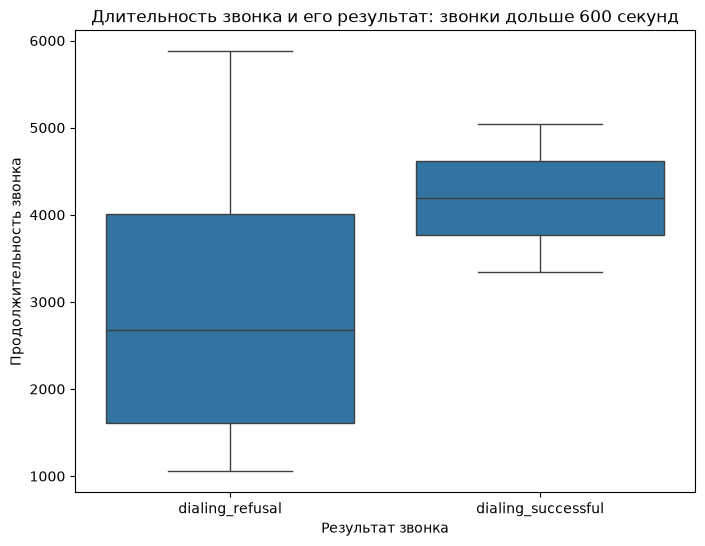

In [24]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='duratoin_result', y='duratoin_sec', data=df_long)
plt.title('Длительность звонка и его результат: звонки дольше 600 секунд')
plt.xlabel('Результат звонка')
plt.ylabel('Продолжительность звонка')
plt.show()

На боксплоте всего 16 звонков дольше 10 минут (14 отказов и 2 успешных), поэтому по нему нельзя делать выводы о том, сколько времени стоит тратить на звонок.

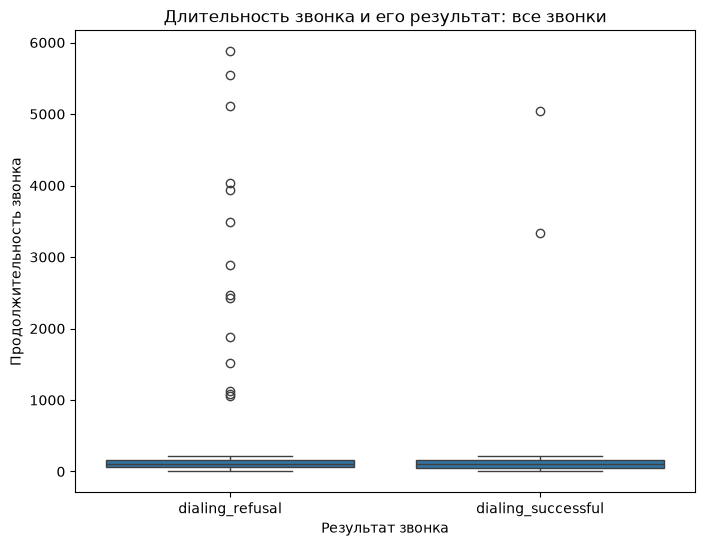

In [25]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='duratoin_result', y='duratoin_sec', data=df)
plt.title('Длительность звонка и его результат: все звонки')
plt.xlabel('Результат звонка')
plt.ylabel('Продолжительность звонка')
plt.show()

Распределения длительности у успешных звонков и у отказов почти совпадают. Вместе с тестами выше это говорит о том, что длительность звонка не связана с его результатом. При этом длительность — следствие разговора, а не рычаг: из этих данных нельзя сделать вывод, что звонки нужно сокращать или удлинять.

## Знак зодиака оператора

In [26]:
create_temp("Count_Conversion", """
SELECT hit_status_result_id, horoscope.horoscope, CAST(REPLACE(call.duratoin_sec, ',', '.') AS REAL) AS duratoin_sec
FROM action
LEFT JOIN call ON action.hit_rk = call.wo_hit_rk
LEFT JOIN horoscope ON horoscope.agent_login = call.agent_login
WHERE hit_status_result_id = 3 or hit_status_result_id = 1
""")

In [27]:
create_temp("count_horoscope", """
SELECT COUNT(horoscope.horoscope), horoscope
FROM horoscope
GROUP BY horoscope
ORDER BY COUNT(horoscope.horoscope) DESC
""")

In [28]:
df_horoscope = q("""
SELECT
    cc.horoscope,
    ROUND(SUM(CASE WHEN cc.hit_status_result_id = 3 THEN 1 ELSE 0 END) * 1.0 /
    NULLIF(SUM(CASE WHEN cc.hit_status_result_id = 1 OR cc.hit_status_result_id = 3 THEN 1 ELSE 0 END), 0), 4) AS zodiac_sign_ratio,
    ROUND(AVG(cc.duratoin_sec), 4) AS duratoin_sec_avg,
    COUNT(cc.hit_status_result_id) AS Count_dialing,
    ch."COUNT(horoscope.horoscope)" AS count_horoscope_agent,
    SUM(CASE WHEN cc.hit_status_result_id = 1 THEN 1 ELSE 0 END) AS unsuccessful_calls,
    SUM(CASE WHEN cc.hit_status_result_id = 3 THEN 1 ELSE 0 END) AS successful_calls
FROM
    Count_Conversion cc
LEFT JOIN
    count_horoscope ch ON cc.horoscope = ch.horoscope
GROUP BY
    cc.horoscope, ch."COUNT(horoscope.horoscope)"
ORDER BY
    zodiac_sign_ratio DESC
""")
df_horoscope = add_wilson_ci(df_horoscope, 'successful_calls', 'Count_dialing')
df_horoscope

,horoscope,zodiac_sign_ratio,duratoin_sec_avg,Count_dialing,count_horoscope_agent,unsuccessful_calls,successful_calls,ci_low,ci_high
0,Стрелец,0.2109,108.6863,1067,316,842,225,0.1875,0.2364
1,Скорпион,0.1996,113.5208,471,70,377,94,0.1660,0.2380
2,Близнецы,0.1877,106.8286,1721,120,1398,323,0.1699,0.2068
3,Овен,0.1655,109.6166,1166,88,973,193,0.1453,0.1879
4,Дева,0.1569,115.1964,8883,785,7489,1394,0.1495,0.1646
5,Водолей,0.1479,112.4029,1332,93,1135,197,0.1298,0.1680
6,Весы,0.1369,110.7622,1636,125,1412,224,0.1211,0.1544
7,Лев,0.1337,113.7641,329,28,285,44,0.1012,0.1748
8,Козерог,0.1320,112.9860,659,46,572,87,0.1083,0.1600
9,Рак,0.1290,109.1806,1814,125,1580,234,0.1144,0.1452


По сырым цифрам у «Стрельцов» наивысшая продажная конверсия (21%), у «Тельцов» — наименьшая (9,7%), и их доверительные интервалы не пересекаются со средней. Но это расчёт по звонкам; проверка на уровне операторов — ниже.

Само распределение знаков неестественное: при примерно равномерном распределении дней рождения на каждый знак приходилось бы около 8% операторов, а здесь 40% «Дев» (785 из 1 962) и 16% «Стрельцов» (316). Скорее всего, это значение по умолчанию или ошибка при заполнении справочника, а не особенность найма.

In [29]:
df = q("""
SELECT cc.horoscope, cc.duratoin_sec, CASE WHEN cc.hit_status_result_id = 3 THEN 'successful' WHEN cc.hit_status_result_id = 1 THEN 'unsuccessful' ELSE 'unknown' END AS call_status FROM Count_Conversion cc
""")


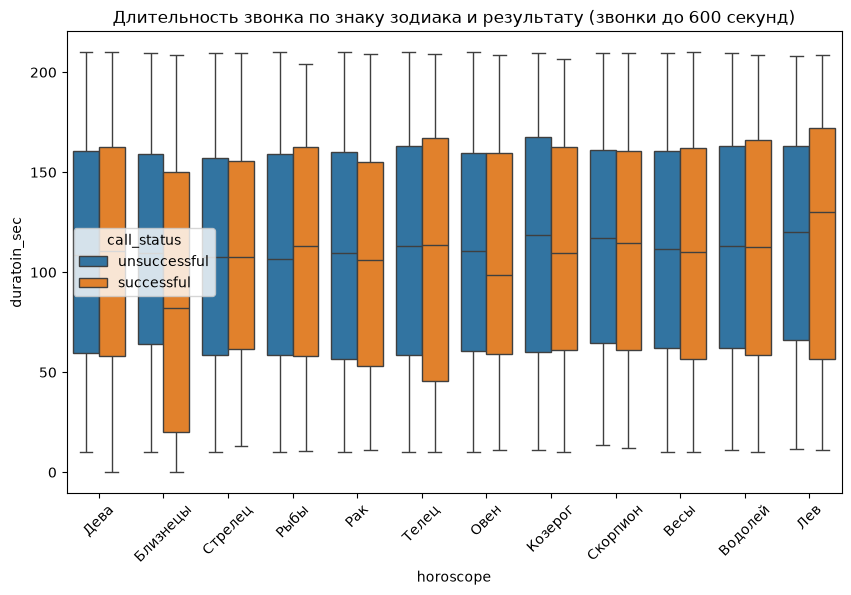

Test Levene, p-value: 0.5084654442481703
                                  df        sum_sq       mean_sq         F  \
C(horoscope)                    11.0  5.009701e+04   4554.273928  1.345758   
C(call_status)                   1.0  1.691734e+04  16917.337643  4.998963   
C(horoscope):C(call_status)     11.0  1.132611e+05  10296.462795  3.042538   
Residual                     21729.0  7.353462e+07   3384.169536       NaN   

                               PR(>F)  
C(horoscope)                 0.191772  
C(call_status)               0.025373  
C(horoscope):C(call_status)  0.000445  
Residual                          NaN  


In [30]:
# Исключение звонков с длительностью более 600 секунд
df_clean = df[df['duratoin_sec'] <= 600]

# Визуализация распределения
plt.figure(figsize=(10, 6))
sns.boxplot(x='horoscope', y='duratoin_sec', hue='call_status', data=df_clean)
plt.xticks(rotation=45)
plt.title('Длительность звонка по знаку зодиака и результату (звонки до 600 секунд)')
plt.show()

# Проверка гомогенности дисперсий (тест Левена)
stat, p_value = stats.levene(*[df_clean[df_clean['horoscope'] == sign]['duratoin_sec'] for sign in df_clean['horoscope'].unique()])
print(f'Test Levene, p-value: {p_value}')

# ANOVA по длительности: знак зодиака, статус звонка и их взаимодействие
anova_model = ols('duratoin_sec ~ C(horoscope) * C(call_status)', data=df_clean).fit()
anova_table = anova_lm(anova_model)
print(anova_table)

Тест Левена (p = 0,51) не отвергает равенство дисперсий.

ANOVA проверяет длительность звонков, а не конверсию. Средняя длительность между знаками не различается (p = 0,19). Значимое взаимодействие знака и статуса (p < 0,001) означает лишь, что разница в длительности между успешными звонками и отказами у разных знаков разная. О связи знака зодиака с продажной конверсией этот тест ничего не говорит — проверим её отдельно.

### Связь знака зодиака с конверсией: проверка на уровне операторов

Хи-квадрат по звонкам считает 21 тыс. звонков независимыми, хотя их сделали около 1 960 операторов, и знак у всех звонков оператора один. Если несколько сильных операторов или групп случайно оказались одного знака, такой тест покажет «значимую» связь. Поэтому проверяем тремя способами:

1. хи-квадрат по звонкам — для сравнения;
2. перестановочный тест: знаки перемешиваются между операторами, а все звонки оператора остаются при нём (второй вариант — перемешивание только внутри одного управления);
3. логистическая регрессия с учётом группы оператора, времени звонка и продукта, ошибки кластеризованы по оператору.

«Успешные» звонки нулевой длительности (аномалия выше) из проверок исключаем.

In [31]:
# Звонки с результатом «Успешно»/«Отказ» из витрины без аномальных «успехов» нулевой длительности
decided = q("""
SELECT agent_login, horoscope, group_nm, management_nm, source_system_cd, product_hid, is_weekend, is_night, is_success
FROM calls
WHERE is_decided AND NOT (is_success AND duration_sec = 0)
""")
agent_clusters = decided['agent_login'].astype('category').cat.codes

# 1) Хи-квадрат по звонкам
zodiac_table = pd.crosstab(decided['horoscope'], decided['is_success'])
print(f"Хи-квадрат по звонкам: p = {chi2_contingency(zodiac_table)[1]:.1e}")

# 2) Перестановочные тесты по операторам
agents = decided.groupby('agent_login').agg(horoscope=('horoscope', 'first'), management_nm=('management_nm', 'first'),
                                            successes=('is_success', 'sum'), calls=('is_success', 'size'))
sign_codes = pd.Categorical(agents['horoscope']).codes
management_idx = [np.flatnonzero(agents['management_nm'].values == m) for m in agents['management_nm'].unique()]
rng = np.random.default_rng(42)


def zodiac_chi2(codes):
    s = np.bincount(codes, weights=agents['successes'], minlength=12)
    n = np.bincount(codes, weights=agents['calls'], minlength=12)
    return chi2_contingency(np.column_stack([s, n - s]))[0]


def shuffle_within_management(codes):
    codes = codes.copy()
    for idx in management_idx:
        codes[idx] = rng.permutation(codes[idx])
    return codes


observed = zodiac_chi2(sign_codes)
perm_all = np.array([zodiac_chi2(rng.permutation(sign_codes)) for _ in range(2000)])
perm_within = np.array([zodiac_chi2(shuffle_within_management(sign_codes)) for _ in range(2000)])
print(f"Перестановочный тест по операторам: p = {(1 + (perm_all >= observed).sum()) / (1 + len(perm_all)):.4f}")
print(f"То же внутри управлений: p = {(1 + (perm_within >= observed).sum()) / (1 + len(perm_within)):.4f}")

Хи-квадрат по звонкам: p = 6.2e-16


Перестановочный тест по операторам: p = 0.0005
То же внутри управлений: p = 0.0200


In [32]:
# 3) Логистическая регрессия: знак зодиака (относительно «Девы») при учёте группы, времени и продукта.
# Малые группы (меньше 100 звонков с результатом) объединены в «Другие»
group_size = decided.groupby('group_nm')['is_success'].transform('size')
decided['group'] = np.where(group_size >= 100, decided['group_nm'], 'Другие')

zodiac_model = smf.logit(
    "is_success ~ C(horoscope, Treatment('Дева')) + C(group) + is_weekend + is_night + C(product_hid)", data=decided
).fit(disp=0, cov_type='cluster', cov_kwds={'groups': agent_clusters})

sign_terms = [name for name in zodiac_model.params.index if 'horoscope' in name]
R = np.eye(len(zodiac_model.params))[[zodiac_model.params.index.get_loc(t) for t in sign_terms]]
print(f"Совместный тест знака зодиака (Вальд): p = {float(zodiac_model.wald_test(R, scalar=True).pvalue):.4f}")
odds_ratios(zodiac_model, sign_terms).rename(index=lambda t: t.split('[T.')[1].rstrip(']')).sort_values('odds_ratio')

Совместный тест знака зодиака (Вальд): p = 0.0102


,odds_ratio,ci_low,ci_high,p_value
Телец,0.6415,0.5139,0.8007,0.0001
Лев,0.9236,0.6710,1.2711,0.6256
Весы,0.9533,0.7880,1.1532,0.6222
Рак,0.9925,0.8111,1.2145,0.9418
Стрелец,1.0232,0.8384,1.2488,0.8212
Рыбы,1.0335,0.7972,1.3398,0.8037
Скорпион,1.0915,0.8261,1.4422,0.5381
Козерог,1.1076,0.8053,1.5235,0.5296
Близнецы,1.1223,0.8905,1.4145,0.3284
Водолей,1.1351,0.9111,1.4141,0.2587


Итог по знаку зодиака:

* по звонкам связь выглядит очень сильной (p = 6·10⁻¹⁶), но при перемешивании знаков между операторами p = 0,0005, а внутри одного управления — уже 0,02;
* в регрессии с учётом группы оператора «Стрельцы» ничем не отличаются от «Дев» (отношение шансов 1,02, p = 0,82): их высокая сырая конверсия объясняется тем, что они чаще работают в сильных группах — например, в Керсе это 29% операторов;
* отличаются только «Тельцы»: шансы на успех у них на треть ниже (отношение шансов 0,64, 95% ДИ 0,51–0,80, p = 0,0001), и это остаётся значимым с поправкой Бонферрони на 11 сравнений.

Причинной связи между знаком зодиака и продажами быть не может. С учётом странного распределения знаков вероятнее, что «Телец» здесь — метка какой-то подгруппы операторов (например, сотрудников, у которых дата рождения заполнена одинаково). Искать стоит именно её, а не подбирать операторов по гороскопу.

## Операторы, группы и управления

### Рейтинг операторов

In [33]:
create_temp("Count_Conversion_For_management", """
SELECT
t1.source_system_cd,
t2.agent_login,
t2.finish_dttm AS finish_dttm_end_talk,
t3.hit_status_result_id,
t6.hit_status_result_desc,
t8.group_nm,
t9.management_nm,
t4.hid AS product_hid,
t4.using_flg AS product_using_flg
FROM task t1
LEFT JOIN call t2 ON t1.task_rk = t2.wo_task_rk
LEFT JOIN action t3 ON t2.wo_hit_rk = t3.hit_rk
LEFT JOIN product t4 ON t3.hit_rk = t4.hit_rk
LEFT JOIN emp_x_org_gr t5 ON t2.wo_employee_rk = t5.employee_rk
LEFT JOIN result t6 ON t3.hit_status_result_id = t6.hit_status_result_id
LEFT JOIN "group" t8 ON t5.org_group_rk = t8.org_group_rk
LEFT JOIN mngmnt t9 ON t8.org_management_rk = t9.org_management_rk
""")

In [34]:
agents_ranking = q("""
SELECT
    agent_login,
    group_nm,
    management_nm,
    COUNT(hit_status_result_id) AS Count_dialing_for_agent,
    SUM(CASE WHEN hit_status_result_id IN (1, 3) THEN 1 ELSE 0 END) AS Count_decided,
    SUM(CASE WHEN hit_status_result_id = 3 THEN 1 ELSE 0 END) AS Count_success,
    ROUND(SUM(CASE WHEN hit_status_result_id = 3 THEN 1 ELSE 0 END) * 1.0 /
    NULLIF(SUM(CASE WHEN hit_status_result_id IN (1, 3) THEN 1 ELSE 0 END), 0), 4) AS agent_ratio
FROM
    Count_Conversion_For_management
GROUP BY
    agent_login, group_nm, management_nm
HAVING
    Count_decided >= 20 -- порог по звонкам «Успешно» + «Отказ»: только они входят в знаменатель конверсии
ORDER BY
    agent_ratio DESC, Count_decided DESC
""")
# Сортируем по нижней границе 95% интервала Уилсона: так оператор с 20 звонками и конверсией 0.5 не обгоняет
# оператора со 100 звонками и конверсией 0.45 только за счёт случайности
agents_ranking = add_wilson_ci(agents_ranking, 'Count_success', 'Count_decided').sort_values('ci_low', ascending=False)
agents_ranking

,agent_login,group_nm,management_nm,Count_dialing_for_agent,Count_decided,Count_success,agent_ratio,ci_low,ci_high
0,cyanrser,Группа 36,Управление КЦ Чизан,70,70,70,1.0000,0.9480,1.0000
1,8925iyuf,Группа 6,Управление КЦ Ребус,40,23,11,0.4783,0.2924,0.6704
2,tovanrnu,Группа 17,Управление КЦ Керс,49,27,12,0.4444,0.2759,0.6269
3,hevatval,Группа 6,Управление КЦ Ребус,40,21,9,0.4286,0.2447,0.6345
4,0251agya,Группа 36,Управление КЦ Чизан,74,22,9,0.4091,0.2326,0.6127
5,6013mxdy,Группа 13,Управление КЦ Дирис,51,21,8,0.3810,0.2075,0.5912
8,lovaepch,Группа 36,Управление КЦ Чизан,83,29,10,0.3448,0.1994,0.5265
7,syanaosa,Группа 36,Управление КЦ Чизан,126,23,8,0.3478,0.1881,0.5511
6,tyansmka,Группа 30,Управление КЦ Чизан,57,20,7,0.3500,0.1812,0.5671
9,3400aava,Группа 36,Управление КЦ Чизан,81,24,8,0.3333,0.1797,0.5329


Рейтинг строится по операторам хотя бы с 20 звонками «Успешно» + «Отказ» и сортируется по нижней границе 95% доверительного интервала. Порог считается именно по звонкам с результатом: если считать его по всем звонкам (включая недозвоны), в лидеры попадают операторы с конверсией 1.0 всего по 1–7 звонкам с результатом. Даже при пороге в 20 звонков интервалы широкие: у второго места (8925iyuf, 11 успехов из 23) конверсия может быть от 29% до 67%, поэтому сравнивать отдельных операторов по месяцу данных надо осторожно.

Первое место занимает cyanrser, но его результат аномален (см. «успешные» звонки нулевой длительности выше). Операторов Керса и Хирса в рейтинге почти нет: у каждого из них меньше 20 звонков с результатом (в среднем 8–9), хотя у самих управлений конверсия наивысшая — она складывается из множества операторов с небольшим числом звонков. Почти половина первой двадцатки — из Чизана, самого крупного управления.

In [35]:
# Все операторы — для выгрузки в Excel
df_agent_ratio = q("""
SELECT
    agent_login,
    group_nm,
    management_nm,
    COUNT(hit_status_result_id) AS Count_dialing_for_agent,
    SUM(CASE WHEN hit_status_result_id IN (1, 3) THEN 1 ELSE 0 END) AS Count_decided,
    SUM(CASE WHEN hit_status_result_id = 3 THEN 1 ELSE 0 END) AS Count_success,
    ROUND(SUM(CASE WHEN hit_status_result_id = 3 THEN 1 ELSE 0 END) * 1.0 /
    NULLIF(SUM(CASE WHEN hit_status_result_id IN (1, 3) THEN 1 ELSE 0 END), 0), 4) AS agent_ratio
FROM
    Count_Conversion_For_management
WHERE
    agent_login IS NOT NULL
GROUP BY
    agent_login, group_nm, management_nm
ORDER BY
    agent_ratio DESC, Count_decided DESC
""")
df_agent_ratio = add_wilson_ci(df_agent_ratio, 'Count_success', 'Count_decided')
df_agent_ratio

,agent_login,group_nm,management_nm,Count_dialing_for_agent,Count_decided,Count_success,agent_ratio,ci_low,ci_high
0,cyanrser,Группа 36,Управление КЦ Чизан,70,70,70,1.0,0.9480,1.0
1,yrovibna,Группа 17,Управление КЦ Керс,25,7,7,1.0,0.6457,1.0
2,1878asig,Группа 6,Управление КЦ Ребус,15,6,6,1.0,0.6097,1.0
3,9302atar,Группа 36,Управление КЦ Чизан,14,5,5,1.0,0.5655,1.0
4,movagsya,Группа 17,Управление КЦ Керс,36,5,5,1.0,0.5655,1.0
5,ninayuvd,Группа 2,Управление КЦ Хирс,25,5,5,1.0,0.5655,1.0
6,ovojmyut,Группа 37,Управление КЦ Страница,11,5,5,1.0,0.5655,1.0
7,6265aavo,Группа 37,Управление КЦ Страница,7,4,4,1.0,0.5101,1.0
8,dinayuas,Группа 2,Управление КЦ Хирс,38,4,4,1.0,0.5101,1.0
9,lovazmba,Группа 17,Управление КЦ Керс,21,4,4,1.0,0.5101,1.0


### Лучший оператор в каждом управлении

In [36]:
create_temp("temper", """
SELECT
    agent_login,
    group_nm,
    management_nm,
    COUNT(hit_status_result_id) AS Count_dialing_for_agent,
    SUM(CASE WHEN hit_status_result_id IN (1, 3) THEN 1 ELSE 0 END) AS Count_decided,
    ROUND(SUM(CASE WHEN hit_status_result_id = 3 THEN 1 ELSE 0 END) * 1.0 /
    NULLIF(SUM(CASE WHEN hit_status_result_id IN (1, 3) THEN 1 ELSE 0 END), 0), 4) AS agent_ratio
FROM
    Count_Conversion_For_management
GROUP BY
    agent_login, group_nm, management_nm
HAVING
    Count_decided >= 20
""")

In [37]:
# Лучший оператор в каждом управлении; при равной конверсии — тот, у кого больше звонков с результатом
df_agent_ratio_by_management = q("""
SELECT agent_login, group_nm, management_nm, Count_dialing_for_agent, Count_decided, agent_ratio
FROM (
    SELECT *, ROW_NUMBER() OVER (PARTITION BY management_nm ORDER BY agent_ratio DESC, Count_decided DESC) AS rn
    FROM temper
)
WHERE rn = 1
ORDER BY agent_ratio DESC, Count_decided DESC
""")
df_agent_ratio_by_management

,agent_login,group_nm,management_nm,Count_dialing_for_agent,Count_decided,agent_ratio
0,cyanrser,Группа 36,Управление КЦ Чизан,70,70,1.0000
1,8925iyuf,Группа 6,Управление КЦ Ребус,40,23,0.4783
2,tovanrnu,Группа 17,Управление КЦ Керс,49,27,0.4444
3,6013mxdy,Группа 13,Управление КЦ Дирис,51,21,0.3810
4,6661onko,Группа 29,Управление КЦ Дирим,95,21,0.2857
5,3443esvo,Группа 5,Управление КЦ Ромашка,94,25,0.2800
6,ievazazh,Группа 3,Управление КЦ Кирис,58,23,0.2609
7,enkolplu,Группа 1,Управление КЦ Пирс,61,23,0.2609
8,xovakvmo,Группа 31,Управление КЦ Казан,135,31,0.2581
9,zovaabko,Группа 19,Управление КЦ Верс,112,24,0.2500


### Конверсия по группам и продуктам

In [38]:
# Все звонки с управлением, группой и продуктом
df_ccm = q("SELECT * FROM Count_Conversion_For_management")

# Группировка данных по управлению, группе и hid (идентификатор продукта)
group_counts = df_ccm.groupby(['management_nm', 'group_nm', 'product_hid']).agg(
    Refuse=pd.NamedAgg(column='hit_status_result_id', aggfunc=lambda x: (x == 1).sum()),
    success=pd.NamedAgg(column='hit_status_result_id', aggfunc=lambda x: (x == 3).sum())
)

# Расчет конверсии продаж
group_counts['Sales_conversion'] = group_counts['success'] / (group_counts['Refuse'] + group_counts['success'])

# Оставляем сочетания хотя бы с 20 звонками «Успешно»/«Отказ», иначе в лидеры попадают строки вида «1 из 1»
df_cleaned = group_counts[(group_counts['Refuse'] + group_counts['success']) >= 20].copy()

# Переименование для ясности
df_management_group_hid_sales = df_cleaned

# Сначала добавим столбец с максимальными значениями Sales_conversion для каждого management_nm
df_management_group_hid_sales['max_sales_conversion'] = df_management_group_hid_sales.groupby('management_nm')['Sales_conversion'].transform('max')

# Сортировка по максимальным значениям Sales_conversion для management_nm,
# затем по значениям Sales_conversion для product_hid
df_management_group_hid_sales_sorted = df_management_group_hid_sales.sort_values(
    by=['max_sales_conversion', 'Sales_conversion'], ascending=[False, False]
).drop(columns='max_sales_conversion')  # Убираем временный столбец
# Вывести отсортированный DataFrame
df_management_group_hid_sales_sorted

Refuse  success  Sales_conversion
management_nm         group_nm  product_hid                                   
Управление КЦ Керс    Группа 17 1                21       52          0.712329
                                4                85      195          0.696429
                      Группа 38 1                30        9          0.230769
                                4                40        9          0.183673
                                2               110       22          0.166667
Управление КЦ Хирс    Группа 2  4                38       88          0.698413
                                1                65      101          0.608434
Управление КЦ Дилис   Группа 32 4                 8       13          0.619048
Управление КЦ Ребус   Группа 6  1                38       56          0.595745
                                4                69       63          0.477273
...                                             ...      ...               ...
Управление КЦ Неп     Группа 48 2               127        6          0.045113
Управление КЦ Помидор Группа 24 4               100        9          0.082569
                                2                34        0          0.000000
Управление КЦ Пирис   Группа 11 4                73        5          0.064103
Управление КЦ Супер   Группа 42 4                75        5          0.062500
Управление КЦ Тирс    Группа 51 2                77        5          0.060976
Управление КЦ Лес     Группа 8  2                91        5          0.052083
                                1                22        1          0.043478
Управление КЦ Вышка   Группа 35 2                60        0          0.000000
Управление КЦ Карис   Группа 40 4                22        0          0.000000

[117 rows x 3 columns]

In [39]:
# Конверсия по группам внутри управлений (без разбивки по продуктам)
df_management_group_by_group_nm = (
    df_ccm.groupby(['management_nm', 'group_nm'])['hit_status_result_id']
    .agg(refuses=lambda x: (x == 1).sum(), success=lambda x: (x == 3).sum())
    .reset_index()
    .rename(columns={'management_nm': 'management'})
)
df_management_group_by_group_nm['sales_conversion'] = (
    df_management_group_by_group_nm['success']
    / (df_management_group_by_group_nm['refuses'] + df_management_group_by_group_nm['success'])
)
df_management_group_by_group_nm = df_management_group_by_group_nm.dropna(subset=['sales_conversion'])
df_management_group_by_group_nm

,management,group_nm,refuses,success,sales_conversion
1,Управление КЦ Варис,Группа 12,20,4,0.166667
2,Управление КЦ Верс,Группа 18,209,17,0.075221
3,Управление КЦ Верс,Группа 19,1186,124,0.094656
4,Управление КЦ Вилис,Группа 7,432,63,0.127273
6,Управление КЦ Вышка,Группа 35,89,2,0.021978
7,Управление КЦ Дарис,Группа 27,88,10,0.102041
8,Управление КЦ Дерс,Группа 10,47,6,0.113208
9,Управление КЦ Дилис,Группа 32,9,13,0.590909
10,Управление КЦ Дирим,Группа 29,1145,115,0.091270
11,Управление КЦ Дирис,Группа 13,427,153,0.263793


Все управления продают одни и те же продукты. Высокая конверсия лидеров держится по каждому их продукту: в группе 17 Керса — 71% по продукту 1 и 70% по продукту 4, в Хирсе — 61% и 70%. Значит, она не объясняется набором продуктов. Проверим, зависит ли результат звонка от продукта в целом.

In [40]:
df_ccm.head()

,source_system_cd,agent_login,finish_dttm_end_talk,hit_status_result_id,hit_status_result_desc,group_nm,management_nm,product_hid,product_using_flg
0,FW,movakaro,2022-08-25 16:13:02,5,Недозвон,Группа 16,Управление КЦ Сезам,4,NaN
1,GI,8306aava,2022-08-02 13:34:55,1,"Дозвон, Отказ",Группа 23,Управление КЦ Страница,4,NaN
2,GI,8251nsma,2022-08-08 22:07:29,1,"Дозвон, Отказ",Группа 36,Управление КЦ Чизан,3,NaN
3,GI,9185avis,2022-08-04 13:59:51,3,"Дозвон, Успешно",Группа 2,Управление КЦ Хирс,4,0.0
4,GI,tevapasa,2022-08-15 11:12:08,1,"Дозвон, Отказ",Группа 29,Управление КЦ Дирим,4,NaN


In [41]:
# 1. Фильтр данных: оставить только "Дозвон, Успешно" и "Дозвон, Отказ"
filtered_df = df_ccm[df_ccm['hit_status_result_desc'].isin(['Дозвон, Успешно', 'Дозвон, Отказ'])].copy()

# 2. Убедимся, что переменные категориальные
filtered_df['product_hid'] = filtered_df['product_hid'].astype('category')
filtered_df['hit_status_result_desc'] = filtered_df['hit_status_result_desc'].astype('category')

# 3. Создать таблицу сопряженности (контингентную таблицу)
contingency_table = pd.crosstab(filtered_df['product_hid'], filtered_df['hit_status_result_desc'])

# 4. Применить критерий хи-квадрат (Chi-Square Test)
chi2, p, dof, expected = chi2_contingency(contingency_table)

# 5. Вывод результатов
print("Таблица сопряженности:")
print(contingency_table)
print("\nХи-квадрат:", chi2)
print("p-значение:", p)
print("Степени свободы:", dof)
print("\nОжидаемые значения:")
print(expected)

Таблица сопряженности:
hit_status_result_desc  Дозвон, Отказ  Дозвон, Успешно
product_hid                                           
1                                1466              429
2                                4714              586
3                                 868              168
4                               11411             2127

Хи-квадрат: 155.47112816081014
p-значение: 1.739423581551826e-33
Степени свободы: 3

Ожидаемые значения:
[[ 1606.86319996   288.13680004]
 [ 4494.12926639   805.87073361]
 [  878.47507924   157.52492076]
 [11479.53245441  2058.46754559]]


Результат звонка зависит от продукта (хи-квадрат, p < 0,001). Конверсия по продуктам: 1 — 22,6%, 3 — 16,2%, 4 — 15,7%, 2 — 11,1%.

В регрессии с учётом управления, времени звонка и источника задачи (раздел «Выходные и вечер: время или операторы?» ниже) значимо отличается только продукт 2: шансы продать его на 38% ниже, чем продукт 1. Разница между продуктами 1, 3 и 4 объясняется тем, какие управления их продают.

### Лучшая группа в каждом управлении

In [42]:
q("""
WITH Group_Conversion AS (
    SELECT
        group_nm,
        management_nm,
        COUNT(hit_status_result_id) AS Count_dialing_for_group,
        SUM(CASE WHEN hit_status_result_id IN (1, 3) THEN 1 ELSE 0 END) AS Count_decided,
        ROUND(SUM(CASE WHEN hit_status_result_id = 3 THEN 1 ELSE 0 END) * 1.0 /
        NULLIF(SUM(CASE WHEN hit_status_result_id IN (1, 3) THEN 1 ELSE 0 END), 0), 4) AS group_nm_ratio
    FROM
        Count_Conversion_For_management
    GROUP BY
        group_nm, management_nm
    HAVING
        Count_decided >= 100 -- порог по звонкам «Успешно» + «Отказ»
)
SELECT *
FROM (
    SELECT
        *,
        ROW_NUMBER() OVER (PARTITION BY management_nm ORDER BY group_nm_ratio DESC) AS rn
    FROM
        Group_Conversion
) AS ranked_groups
WHERE rn = 1
ORDER BY group_nm_ratio DESC
""")

,group_nm,management_nm,Count_dialing_for_group,Count_decided,group_nm_ratio,rn
0,Группа 17,Управление КЦ Керс,1434,373,0.6890,1
1,Группа 2,Управление КЦ Хирс,1274,301,0.6478,1
2,Группа 6,Управление КЦ Ребус,549,260,0.5000,1
3,Группа 37,Управление КЦ Страница,672,202,0.3861,1
4,Группа 15,Управление КЦ Шоколад,1831,413,0.3075,1
5,Группа 13,Управление КЦ Дирис,2208,580,0.2638,1
6,Группа 30,Управление КЦ Чизан,4633,1143,0.1820,1
7,Группа 1,Управление КЦ Пирс,1424,353,0.1558,1
8,Группа 41,Управление КЦ Парис,4350,1096,0.1505,1
9,Группа 45,Управление КЦ Мазан,2715,881,0.1385,1


In [43]:
df_group = q("""
SELECT
        group_nm,
        management_nm,
        COUNT(hit_status_result_id) AS Count_dialing_for_group,
        SUM(CASE WHEN hit_status_result_id IN (1, 3) THEN 1 ELSE 0 END) AS Count_decided,
        SUM(CASE WHEN hit_status_result_id = 3 THEN 1 ELSE 0 END) AS Count_success,
        ROUND(SUM(CASE WHEN hit_status_result_id = 3 THEN 1 ELSE 0 END) * 1.0 /
        NULLIF(SUM(CASE WHEN hit_status_result_id IN (1, 3) THEN 1 ELSE 0 END), 0), 4) AS group_nm_ratio
FROM Count_Conversion_For_management
GROUP BY group_nm, management_nm
HAVING Count_decided >= 100
ORDER BY group_nm_ratio DESC
""")
df_group = add_wilson_ci(df_group, 'Count_success', 'Count_decided')
# Сохраняем в df для дальнейшего сохранения в excel
df_group

,group_nm,management_nm,Count_dialing_for_group,Count_decided,Count_success,group_nm_ratio,ci_low,ci_high
0,Группа 17,Управление КЦ Керс,1434,373,257,0.6890,0.6403,0.7339
1,Группа 2,Управление КЦ Хирс,1274,301,195,0.6478,0.5923,0.6996
2,Группа 6,Управление КЦ Ребус,549,260,130,0.5000,0.4397,0.5603
3,Группа 37,Управление КЦ Страница,672,202,78,0.3861,0.3217,0.4548
4,Группа 15,Управление КЦ Шоколад,1831,413,127,0.3075,0.2649,0.3536
5,Группа 13,Управление КЦ Дирис,2208,580,153,0.2638,0.2296,0.3011
6,Группа 30,Управление КЦ Чизан,4633,1143,208,0.1820,0.1607,0.2054
7,Группа 38,Управление КЦ Керс,927,223,40,0.1794,0.1346,0.2350
8,Группа 36,Управление КЦ Чизан,16705,3914,662,0.1691,0.1577,0.1812
9,Группа 1,Управление КЦ Пирс,1424,353,55,0.1558,0.1217,0.1973


Наивысшая конверсия — у группы 17 Керса (69%) и группы 2 Хирса (65%). У второй группы Керса (группа 38) — всего 18%, то есть высокая конверсия Керса держится на одной группе.

### Конверсия по управлениям

In [44]:
df_management = q("""
SELECT
    management_nm,
    COUNT(hit_status_result_id) AS Count_dialing_for_management,
    SUM(CASE WHEN hit_status_result_id IN (1, 3) THEN 1 ELSE 0 END) AS Count_decided,
    SUM(CASE WHEN hit_status_result_id = 3 THEN 1 ELSE 0 END) AS Count_success,
    SUM(CASE WHEN hit_status_result_id = 3 THEN 1 ELSE 0 END) * 1.0 /
    NULLIF(SUM(CASE WHEN hit_status_result_id IN (1, 3) THEN 1 ELSE 0 END), 0) AS management_nm_ratio
FROM Count_Conversion_For_management
WHERE management_nm IS NOT NULL
GROUP BY management_nm
ORDER BY management_nm_ratio DESC
""")
df_management = add_wilson_ci(df_management, 'Count_success', 'Count_decided')
df_management

,management_nm,Count_dialing_for_management,Count_decided,Count_success,management_nm_ratio,ci_low,ci_high
0,Управление КЦ Хирс,1274,301,195,0.647841,0.5923,0.6996
1,Управление КЦ Дилис,58,22,13,0.590909,0.3873,0.7674
2,Управление КЦ Керс,2361,596,297,0.498322,0.4583,0.5383
3,Управление КЦ Ребус,802,371,140,0.377358,0.3295,0.4277
4,Управление КЦ Шоколад,1831,413,127,0.307506,0.2649,0.3536
5,Управление КЦ Дирис,2208,580,153,0.263793,0.2296,0.3011
6,Управление КЦ Чирис,142,38,7,0.184211,0.0922,0.3342
7,Управление КЦ Чизан,21381,5063,870,0.171835,0.1617,0.1825
8,Управление КЦ Чирим,47,12,2,0.166667,0.0470,0.4480
9,Управление КЦ Варис,69,24,4,0.166667,0.0668,0.3585


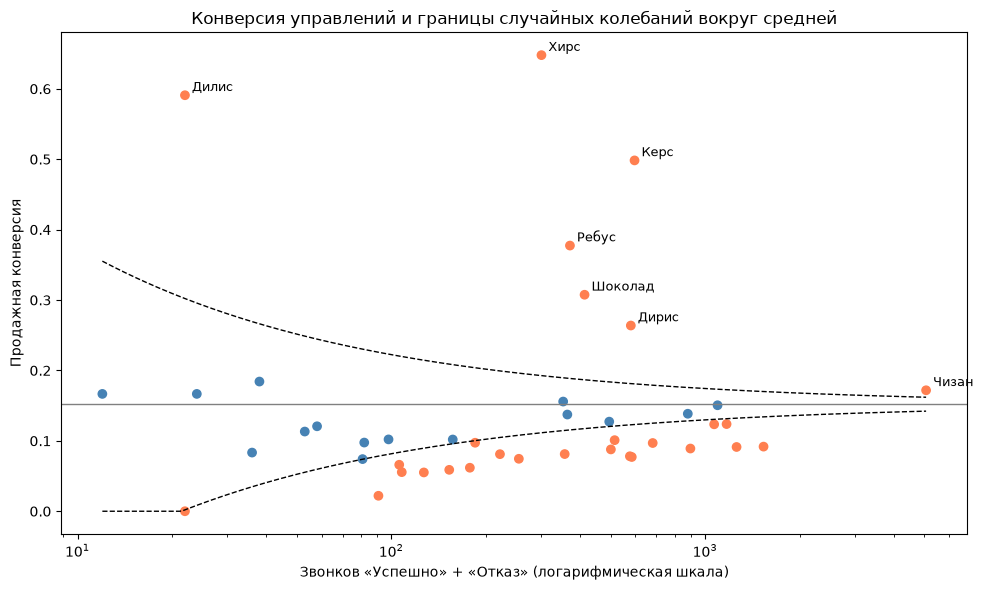

Средняя конверсия: 0.1521
Выше границ: Управление КЦ Хирс, Управление КЦ Дилис, Управление КЦ Керс, Управление КЦ Ребус, Управление КЦ Шоколад, Управление КЦ Дирис, Управление КЦ Чизан
Ниже границ: Управление КЦ Страница, Управление КЦ Ромашка, Управление КЦ Кирис, Управление КЦ Сеньор, Управление КЦ Кирим, Управление КЦ Верс, Управление КЦ Дирим, Управление КЦ Кас, Управление КЦ Мерс, Управление КЦ Сезам, Управление КЦ Мирс, Управление КЦ Неп, Управление КЦ Тазан, Управление КЦ Мас, Управление КЦ Пирис, Управление КЦ Зирс, Управление КЦ Помидор, Управление КЦ Тирс, Управление КЦ Лес, Управление КЦ Вышка, Управление КЦ Карис


In [45]:
# Воронкообразный график: конверсия управления против числа звонков с результатом. Пунктир — 95% границы,
# в которых колебалась бы конверсия управления случайно, если бы у всех управлений она была равна средней
overall = df_management['Count_success'].sum() / df_management['Count_decided'].sum()
plot_df = df_management[df_management['Count_decided'] > 0]
n_grid = np.geomspace(plot_df['Count_decided'].min(), plot_df['Count_decided'].max(), 300)
margin = 1.96 * np.sqrt(overall * (1 - overall) / n_grid)
is_outside = (plot_df['management_nm_ratio'] - overall).abs() > 1.96 * np.sqrt(overall * (1 - overall) / plot_df['Count_decided'])

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(plot_df['Count_decided'], plot_df['management_nm_ratio'], c=np.where(is_outside, 'coral', 'steelblue'))
ax.plot(n_grid, overall + margin, 'k--', linewidth=1)
ax.plot(n_grid, np.clip(overall - margin, 0, None), 'k--', linewidth=1)
ax.axhline(overall, color='gray', linewidth=1)
# Подписываем только управления выше границ: нижние точки слишком плотные, их список — под графиком
for _, row in plot_df[is_outside & (plot_df['management_nm_ratio'] > overall)].iterrows():
    ax.annotate(row['management_nm'].replace('Управление КЦ ', ''), (row['Count_decided'], row['management_nm_ratio']),
                textcoords='offset points', xytext=(5, 3), fontsize=9)
ax.set_xscale('log')
ax.set_xlabel('Звонков «Успешно» + «Отказ» (логарифмическая шкала)')
ax.set_ylabel('Продажная конверсия')
ax.set_title('Конверсия управлений и границы случайных колебаний вокруг средней')
plt.tight_layout()
plt.show()

print(f"Средняя конверсия: {overall:.4f}")
print('Выше границ:', ', '.join(plot_df.loc[is_outside & (plot_df['management_nm_ratio'] > overall), 'management_nm']))
print('Ниже границ:', ', '.join(plot_df.loc[is_outside & (plot_df['management_nm_ratio'] < overall), 'management_nm']))

Пунктир на графике — границы, в которых конверсия управления колебалась бы случайно, если бы у всех управлений она была равна средней (15,2%). Большинство управлений за эти границы выходят, то есть различия между управлениями настоящие, а не случайные:

* выше средней — Хирс (65%), Керс (50%), Ребус (38%), Шоколад (31%), Дирис (26%) и крупнейшее управление Чизан (17%). Дилис (59%) тоже выше границы, но у него всего 22 звонка с результатом;
* ниже средней — 21 управление, в том числе крупные Верс, Дирим, Ромашка и Страница. Хуже всего — Вышка (2%) и Карис (0 из 22).

С ростом числа звонков конверсия управления приближается к ≈0,15, и это ожидаемо: у маленьких управлений доля сильнее колеблется случайно, а крупные сами формируют среднюю — один Чизан даёт почти четверть всех звонков с результатом. Границы на графике не учитывают, что звонки одного оператора не независимы, поэтому для точек у самой границы вывод менее надёжен.

In [46]:
df_virs = q("""
SELECT *
FROM
    Count_Conversion_For_management
WHERE management_nm = 'Управление КЦ Вирс'
""")
df_virs

,source_system_cd,agent_login,finish_dttm_end_talk,hit_status_result_id,hit_status_result_desc,group_nm,management_nm,product_hid,product_using_flg
0,GI,ajloagxo,2022-08-12 10:53:48,5,Недозвон,Группа 4,Управление КЦ Вирс,2,None
1,FW,5275masi,2022-08-16 16:38:24,5,Недозвон,Группа 4,Управление КЦ Вирс,1,None
2,GI,ajloagxo,2022-08-15 14:22:50,5,Недозвон,Группа 4,Управление КЦ Вирс,2,None
3,GI,9694eaav,2022-08-01 14:43:10,5,Недозвон,Группа 4,Управление КЦ Вирс,1,None
4,GI,nayaispo,2022-08-02 12:21:20,5,Недозвон,Группа 4,Управление КЦ Вирс,2,None
5,GI,nayaispo,2022-08-31 17:01:28,5,Недозвон,Группа 4,Управление КЦ Вирс,2,None
6,GI,chukkima,2022-08-25 11:43:04,5,Недозвон,Группа 4,Управление КЦ Вирс,2,None
7,GI,chukkima,2022-08-17 17:03:36,5,Недозвон,Группа 4,Управление КЦ Вирс,2,None
8,GI,sovalmbo,2022-08-04 10:30:44,5,Недозвон,Группа 4,Управление КЦ Вирс,2,None
9,GI,sovalmbo,2022-08-05 12:01:52,5,Недозвон,Группа 4,Управление КЦ Вирс,2,None


У управления Вирс все 251 звонок закончились «Недозвоном» — ни одного разговора за месяц. Случайностью это быть не может: похоже на сбой (например, в настройке очереди или в номерах), который стоит проверить.

In [47]:
df_vazan = q("""
SELECT *
FROM
    Count_Conversion_For_management
WHERE management_nm = 'Управление КЦ Вазан'
""")
df_vazan

,source_system_cd,agent_login,finish_dttm_end_talk,hit_status_result_id,hit_status_result_desc,group_nm,management_nm,product_hid,product_using_flg
0,FW,tyanazha,2022-08-03 11:56:39,5,Недозвон,Группа 39,Управление КЦ Вазан,4,None
1,FW,tyanazha,2022-08-03 11:35:58,5,Недозвон,Группа 39,Управление КЦ Вазан,4,None
2,FW,tyanazha,2022-08-04 11:30:59,6,"Дозвон, Отложить",Группа 39,Управление КЦ Вазан,4,None


У управления Вазан всего 3 звонка за месяц от одного оператора (2 «Недозвона» и 1 «Дозвон, Отложить»). Либо управление только открылось, либо его звонки не попали в базу.

## Время звонка: часы, выходные и дни недели

In [48]:
create_temp("T", """
SELECT
    r.hit_status_result_id,
    c.finish_dttm as finish_dttm_end_talk
FROM
    call c
LEFT JOIN
    action r ON c.wo_hit_rk = r.hit_rk
WHERE
    r.hit_status_result_id IN (1,3)
""")

In [49]:
create_temp("Sales_Conversion_Per_Hour", """
SELECT
    strftime('%H', finish_dttm_end_talk) AS hour_of_day,
    CAST(COUNT(CASE WHEN hit_status_result_id = 3 THEN 1 END) AS FLOAT) / (COUNT(CASE WHEN hit_status_result_id = 3 THEN 1 END) + COUNT(CASE WHEN hit_status_result_id = 1 THEN 1 END)) as Sales_Conversion,
    COUNT(hit_status_result_id) as Count_Dialings,
    COUNT(CASE WHEN hit_status_result_id = 3 THEN 1 END) AS Successful_Calls
FROM T
WHERE hit_status_result_id IN (1, 3)
GROUP BY hour_of_day
""")

In [50]:
q("""
SELECT hour_of_day, ROUND(Sales_Conversion,3) AS Sales_Conversion, Count_Dialings FROM Sales_Conversion_Per_Hour
""")

,hour_of_day,Sales_Conversion,Count_Dialings
0,03,0.000,1
1,04,0.219,32
2,05,0.282,85
3,06,0.113,194
4,07,0.180,334
5,08,0.121,1367
6,09,0.138,1548
7,10,0.134,2534
8,11,0.155,2659
9,12,0.146,2407


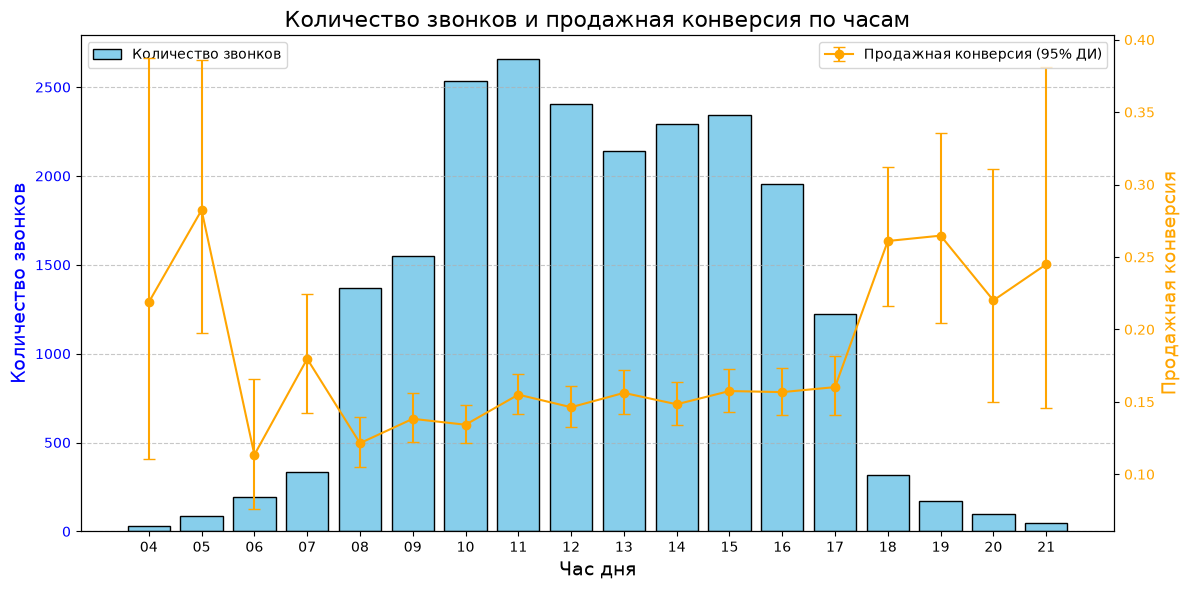

In [51]:
data_df = q("""
SELECT hour_of_day, Sales_Conversion, Count_Dialings, Successful_Calls FROM Sales_Conversion_Per_Hour
""")

data_df = add_wilson_ci(data_df, 'Successful_Calls', 'Count_Dialings')

# Часы, где меньше 30 звонков с результатом, не показываем: конверсия там почти случайна
data_df = data_df[data_df['Count_Dialings'] >= 30]

# Создаем фигуру и оси для комбинированного графика
fig, ax1 = plt.subplots(figsize=(12, 6))

# Гистограмма количества звонков (основная ось Y)
ax1.bar(data_df['hour_of_day'], data_df['Count_Dialings'], color='skyblue', edgecolor='black', label='Количество звонков')
ax1.set_xlabel('Час дня', fontsize=14)
ax1.set_ylabel('Количество звонков', fontsize=14, color='blue')
ax1.tick_params(axis='y', labelcolor='blue')  # Устанавливаем цвет подписей оси Y для звонков
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Линия продажной конверсии (вторая ось Y)
ax2 = ax1.twinx()  # Создаем вторую ось Y
ax2.errorbar(data_df['hour_of_day'], data_df['Sales_Conversion'],
             yerr=[data_df['Sales_Conversion'] - data_df['ci_low'], data_df['ci_high'] - data_df['Sales_Conversion']],
             color='orange', marker='o', capsize=4, label='Продажная конверсия (95% ДИ)')
ax2.set_ylabel('Продажная конверсия', fontsize=14, color='orange')
ax2.tick_params(axis='y', labelcolor='orange')  # Устанавливаем цвет подписей оси Y для конверсии

# Заголовок и настройка графика
plt.title('Количество звонков и продажная конверсия по часам', fontsize=16)
fig.tight_layout()  # Устраняет проблемы с наложением подписей

# Легенда
ax1.legend(loc='upper left')  # Легенда для гистограммы
ax2.legend(loc='upper right')  # Легенда для линейного графика

# Показать график
plt.show()

Видно, что в ночное время звонков значительно меньше, чем в дневное, но выше продажная конверсия. В 18 и 19 часов конверсия (26–27%) выше дневной (12–16%) даже с учётом доверительных интервалов; для 20–21 часа и для раннего утра интервалы слишком широкие, чтобы что-то утверждать.

In [52]:
df_result_for_hour = q("""
SELECT strftime('%H', finish_dttm_end_talk) AS hour_of_day, CAST(COUNT(CASE WHEN hit_status_result_id = 3 THEN 1 END) AS FLOAT) / (COUNT(CASE WHEN hit_status_result_id = 3 THEN 1 END) + COUNT(CASE WHEN hit_status_result_id = 1 THEN 1 END)) as Sales_Conversion, COUNT(hit_status_result_id) as Count_Dialings FROM T WHERE hit_status_result_id IN (1, 3) GROUP BY hour_of_day
""")
df_result_for_hour['hour_of_day'] = df_result_for_hour['hour_of_day'].astype(int)
df_result_for_hour

,hour_of_day,Sales_Conversion,Count_Dialings
0,3,0.000000,1
1,4,0.218750,32
2,5,0.282353,85
3,6,0.113402,194
4,7,0.179641,334
5,8,0.121434,1367
6,9,0.138243,1548
7,10,0.134175,2534
8,11,0.154945,2659
9,12,0.146240,2407


Гипотеза: ночью и рано утром люди охотнее берут трубку. Проверим её и для выходных.

In [53]:
# Доля дозвона — звонки со статусом «Дозвон, …» среди всех попыток дозвона («Дозвон, …» + «Недозвон»).
# Статус «Не было звонка» не учитываем
df_reach = q("""
WITH calls AS (
    SELECT
        CASE WHEN strftime('%w', finish_dttm_end_talk) IN ('0', '6') THEN 'Weekend' ELSE 'Weekday' END AS day_type,
        CASE WHEN strftime('%H', finish_dttm_end_talk) BETWEEN '06' AND '17'
             THEN 'Daytime (06-17)' ELSE 'Nighttime (18-05)' END AS day_part,
        hit_status_result_desc LIKE 'Дозвон%' AS reached
    FROM Count_Conversion_For_management
    WHERE hit_status_result_desc LIKE 'Дозвон%' OR hit_status_result_desc = 'Недозвон'
)
SELECT day_type AS Period, SUM(reached) AS Reached, SUM(1 - reached) AS Not_reached FROM calls GROUP BY day_type
UNION ALL
SELECT day_part, SUM(reached), SUM(1 - reached) FROM calls GROUP BY day_part
""").set_index('Period')
df_reach['Total_Calls'] = df_reach['Reached'] + df_reach['Not_reached']
df_reach['Reach_Percentage'] = (100 * df_reach['Reached'] / df_reach['Total_Calls']).round(2)
df_reach

,Reached,Not_reached,Total_Calls,Reach_Percentage
Period,,,,
Weekday,37101,48738,85839,43.22
Weekend,1482,1723,3205,46.24
Daytime (06-17),37191,48735,85926,43.28
Nighttime (18-05),1392,1726,3118,44.64


In [54]:
def chi2_test(contingency_table, question):
    """Хи-квадрат по таблице фактических количеств и вывод решения на уровне 0.05."""
    chi2, p_value, _, _ = chi2_contingency(contingency_table)
    print("Таблица сопряженности:")
    print(contingency_table)
    print(f"Значение хи-квадрат: {chi2:.2f}")
    print(f"p-значение: {p_value:.4f}")
    if p_value < 0.05:
        print(f"Гипотеза отвергается. Есть значимая разница {question}.")
    else:
        print(f"Гипотеза не может быть отвергнута. Нет значимой разницы {question}.")


chi2_test(df_reach.loc[['Daytime (06-17)', 'Nighttime (18-05)'], ['Reached', 'Not_reached']],
          'в доле дозвона днём и ночью')

Таблица сопряженности:
                   Reached  Not_reached
Period                                 
Daytime (06-17)      37191        48735
Nighttime (18-05)     1392         1726
Значение хи-квадрат: 2.22
p-значение: 0.1366
Гипотеза не может быть отвергнута. Нет значимой разницы в доле дозвона днём и ночью.


In [55]:
chi2_test(df_reach.loc[['Weekend', 'Weekday'], ['Reached', 'Not_reached']],
          'в доле дозвона в выходные и будние дни')

Таблица сопряженности:
         Reached  Not_reached
Period                       
Weekend     1482         1723
Weekday    37101        48738
Значение хи-квадрат: 11.34
p-значение: 0.0008
Гипотеза отвергается. Есть значимая разница в доле дозвона в выходные и будние дни.


Доля дозвона днём (43,3%) и ночью (44,6%) значимо не различается (p = 0,14). В выходные дозваиваются чаще, чем в будни: 46,2% против 43,2% (p < 0,001), но разница — всего 3 процентных пункта. Поэтому более высокую конверсию ночью и в выходные нельзя объяснить тем, что клиенты чаще берут трубку.

Возможно, операторы, которые работают в выходные и вечером, в целом продают лучше тех, кто работает только по будням днём: они более мотивированы и лучше умеют продавать.

In [56]:
df_weekend_workers = q("""
WITH Agent_Working_Status AS (
    SELECT
        agent_login,
        CASE
            WHEN SUM(CASE WHEN strftime('%w', finish_dttm_end_talk) IN ('0', '6') THEN 1 ELSE 0 END) > 0
            THEN 'Weekend_Worker' -- Операторы, работающие в выходные
            ELSE 'Weekday_Only_Worker' -- Операторы, работающие только в будние дни
        END AS Agent_Type
    FROM
        Count_Conversion_For_management
    GROUP BY
        agent_login
)
SELECT
    aws.Agent_Type,
    COUNT(cfm.hit_status_result_id) AS Count_dialing_for_agent,
    SUM(CASE WHEN cfm.hit_status_result_id = 3 THEN 1 ELSE 0 END) AS Successful_Calls,
    SUM(CASE WHEN cfm.hit_status_result_id = 1 THEN 1 ELSE 0 END) AS Refusal_Calls,
    SUM(CASE WHEN cfm.hit_status_result_id = 3 THEN 1 ELSE 0 END) * 1.0 /
    NULLIF(SUM(CASE WHEN cfm.hit_status_result_id IN (1, 3) THEN 1 ELSE 0 END), 0) AS Sales_Conversion
FROM
    Count_Conversion_For_management cfm
JOIN
    Agent_Working_Status aws
    ON cfm.agent_login = aws.agent_login
GROUP BY
    aws.Agent_Type
""")
df_weekend_workers

,Agent_Type,Count_dialing_for_agent,Successful_Calls,Refusal_Calls,Sales_Conversion
0,Weekday_Only_Worker,52214,1696,11442,0.129091
1,Weekend_Worker,36960,1614,7017,0.187000


In [57]:
chi2_test(df_weekend_workers.set_index('Agent_Type')[['Successful_Calls', 'Refusal_Calls']],
          "в конверсии у 'Weekday_Only_Worker' и 'Weekend_Worker'")

Таблица сопряженности:
                     Successful_Calls  Refusal_Calls
Agent_Type                                          
Weekday_Only_Worker              1696          11442
Weekend_Worker                   1614           7017
Значение хи-квадрат: 135.03
p-значение: 0.0000
Гипотеза отвергается. Есть значимая разница в конверсии у 'Weekday_Only_Worker' и 'Weekend_Worker'.


Операторы, которые работают и в выходные, продают лучше: 18,7% против 12,9% у тех, кто работает только по будням.

In [58]:
df_evening_workers = q("""
WITH Agent_Working_Status AS (
    SELECT
        agent_login,
        CASE
            WHEN agent_login IN (
                SELECT DISTINCT agent_login
                FROM Count_Conversion_For_management
                WHERE strftime('%H', finish_dttm_end_talk) BETWEEN '18' AND '23'
                   OR strftime('%H', finish_dttm_end_talk) BETWEEN '00' AND '05'
            ) THEN 'Evening_or_Night_Worker'
            ELSE 'Daytime_Only_Worker'
        END AS Agent_Type
    FROM
        Count_Conversion_For_management
    GROUP BY
        agent_login
)
SELECT
    aws.Agent_Type,
    COUNT(cfm.hit_status_result_id) AS Count_dialing_for_agent,
    SUM(CASE WHEN cfm.hit_status_result_id = 3 THEN 1 ELSE 0 END) AS Successful_Calls,
    SUM(CASE WHEN cfm.hit_status_result_id = 1 THEN 1 ELSE 0 END) AS Refusal_Calls,
    SUM(CASE WHEN cfm.hit_status_result_id = 3 THEN 1 ELSE 0 END) * 1.0 /
    NULLIF(SUM(CASE WHEN cfm.hit_status_result_id IN (1, 3) THEN 1 ELSE 0 END), 0) AS Sales_Conversion
FROM
    Count_Conversion_For_management cfm
JOIN
    Agent_Working_Status aws
    ON cfm.agent_login = aws.agent_login
GROUP BY
    aws.Agent_Type
""")
df_evening_workers

,Agent_Type,Count_dialing_for_agent,Successful_Calls,Refusal_Calls,Sales_Conversion
0,Daytime_Only_Worker,54505,1792,11602,0.133791
1,Evening_or_Night_Worker,34669,1518,6857,0.181254


In [59]:
chi2_test(df_evening_workers.set_index('Agent_Type')[['Successful_Calls', 'Refusal_Calls']],
          "в конверсии у 'Daytime_Only_Worker' и 'Evening_or_Night_Worker'")

Таблица сопряженности:
                         Successful_Calls  Refusal_Calls
Agent_Type                                              
Daytime_Only_Worker                  1792          11602
Evening_or_Night_Worker              1518           6857
Значение хи-квадрат: 89.66
p-значение: 0.0000
Гипотеза отвергается. Есть значимая разница в конверсии у 'Daytime_Only_Worker' и 'Evening_or_Night_Worker'.


Для времени суток вывод такой же: у операторов с вечерними звонками конверсия 18,1% против 13,4% у тех, кто звонит только днём.

Гипотеза: вечером конверсия выше, потому что в это время работают более опытные и мотивированные операторы, а клиенты вечером охотнее соглашаются на покупку. То же может быть верно и для выходных.

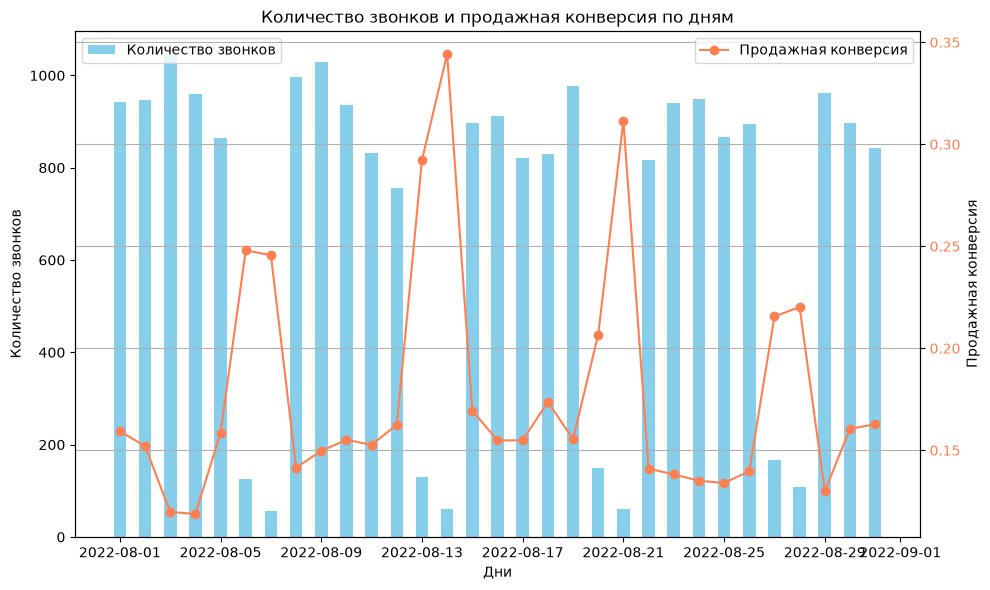

In [60]:
df_days_sales_conversion = q("""
SELECT DATE(finish_dttm_end_talk) AS day,CAST(COUNT(CASE WHEN hit_status_result_id = 3 THEN 1 END) AS FLOAT) / (COUNT(CASE WHEN hit_status_result_id = 3 THEN 1 END) + COUNT(CASE WHEN hit_status_result_id = 1 THEN 1 END)) as Sales_Conversions, COUNT(hit_status_result_id) AS Count_Dialings, COUNT(CASE WHEN hit_status_result_id = 3 THEN 1 END) AS Successful_Calls FROM T WHERE hit_status_result_id IN (1, 3) GROUP BY DATE(finish_dttm_end_talk)
""")


df_days_sales_conversion['day'] = pd.to_datetime(df_days_sales_conversion['day'])
df = df_days_sales_conversion

fig, ax1 = plt.subplots(figsize=(10, 6))

# Гистограмма для количества звонков
ax1.bar(df['day'], df['Count_Dialings'], color='skyblue', label='Количество звонков', width=0.5)
ax1.set_xlabel('Дни')
ax1.set_ylabel('Количество звонков')
ax1.tick_params(axis='y')
ax1.legend(loc='upper left')

# Создаем вторую ось Y для конверсии
ax2 = ax1.twinx()
ax2.plot(df['day'], df['Sales_Conversions'], color='coral', marker='o', label='Продажная конверсия')
ax2.set_ylabel('Продажная конверсия')
ax2.tick_params(axis='y', labelcolor='coral')
ax2.legend(loc='upper right')

plt.title('Количество звонков и продажная конверсия по дням')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [61]:
# Копия, чтобы служебные столбцы не попали в выгрузку в Excel
df = df_days_sales_conversion.copy()

# 1. Добавление столбца с типом дня недели (будний/выходной)
df['day_type'] = df['day'].dt.dayofweek.apply(lambda x: 'weekday' if x < 5 else 'weekend')

# 2. Группировка данных по типу дня и суммирование
agg_df = df.groupby('day_type').agg({'Count_Dialings': 'sum'})

# 3. Количество успешных звонков для каждого типа дня (точные количества из SQL)
agg_df['successful_calls'] = df.groupby('day_type')['Successful_Calls'].sum()


# 4. Расчет конверсии на основе агрегированных данных
agg_df['conversion'] = agg_df['successful_calls'] / agg_df['Count_Dialings']

# 5. Создание таблицы сопряженности
contingency_table = [
    [agg_df.loc['weekday', 'successful_calls'], agg_df.loc['weekday', 'Count_Dialings'] - agg_df.loc['weekday', 'successful_calls']],
    [agg_df.loc['weekend', 'successful_calls'], agg_df.loc['weekend', 'Count_Dialings'] - agg_df.loc['weekend', 'successful_calls']]
]

# 6. Проведение теста хи-квадрат
chi2, p_value, _, _ = chi2_contingency(contingency_table)

# 7. Вывод результатов
print("Агрегированные данные по типу дня:")
print(agg_df)
print("\nТаблица сопряженности:")
print(contingency_table)
print(f"\nЗначение хи-квадрат: {chi2:.2f}")
print(f"p-значение: {p_value:.4f}")

# 8. Проверка гипотезы
alpha = 0.05  # Уровень значимости
if p_value < alpha:
    print("\nГипотеза отвергается. Есть значимая разница между конверсией продаж в будние и выходные дни.")
else:
    print("\nГипотеза не может быть отвергнута. Нет значимой разницы между конверсией продаж в будние и выходные дни.")

Агрегированные данные по типу дня:
          Count_Dialings  successful_calls  conversion
day_type                                              
weekday            20909              3096    0.148070
weekend              860               214    0.248837

Таблица сопряженности:
[[np.int64(3096), np.int64(17813)], [np.int64(214), np.int64(646)]]

Значение хи-квадрат: 64.27
p-значение: 0.0000

Гипотеза отвергается. Есть значимая разница между конверсией продаж в будние и выходные дни.


В выходные продажная конверсия выше, чем в будни: 24,9% против 14,8% (p < 0,001), хотя звонков в выходные в 24 раза меньше. Почему — разберём ниже.

### Выходные и вечер: время или операторы?

Конверсия в выходные и вечером выше, но в это время работают не те же операторы, что днём в будни, и не в тех же пропорциях по управлениям: у Хирса, Керса и Ребуса доля звонков в выходные в 2,5–3,5 раза выше средней. Проверим:

1. остаётся ли эффект, если учесть продукт, источник задачи и управление (логистическая регрессия, ошибки кластеризованы по оператору);
2. выше ли конверсия у **того же самого** оператора в выходные и вечером, чем в остальное время (условная логистическая регрессия по оператору).

In [62]:
# Малые управления (меньше 100 звонков с результатом) объединены в «Другие»
management_size = decided.groupby('management_nm')['is_success'].transform('size')
decided['management'] = np.where(management_size >= 100, decided['management_nm'], 'Другие')

time_models = {
    'только время': 'is_success ~ is_weekend + is_night',
    '+ продукт и источник': 'is_success ~ is_weekend + is_night + C(product_hid) + C(source_system_cd)',
    '+ управление': 'is_success ~ is_weekend + is_night + C(product_hid) + C(source_system_cd) + C(management)',
}
time_results = []
for label, formula in time_models.items():
    time_model = smf.logit(formula, data=decided).fit(disp=0, cov_type='cluster', cov_kwds={'groups': agent_clusters})
    time_results.append(odds_ratios(time_model, ['is_weekend', 'is_night']).assign(model=label))
pd.concat(time_results).reset_index(names='term').set_index(['model', 'term'])

odds_ratio  ci_low  ci_high  p_value
model                term                                            
только время         is_weekend      1.8007  1.5105   2.1467   0.0000
                     is_night        1.8195  1.4991   2.2082   0.0000
+ продукт и источник is_weekend      1.8193  1.5278   2.1663   0.0000
                     is_night        1.8329  1.5075   2.2284   0.0000
+ управление         is_weekend      1.4237  1.1752   1.7246   0.0003
                     is_night        1.7347  1.4075   2.1380   0.0000

In [63]:
# Продукт и источник задачи в полной модели (относительно продукта 1 и источника CM)
odds_ratios(time_model, [t for t in time_model.params.index if 'product_hid' in t or 'source_system_cd' in t])

,odds_ratio,ci_low,ci_high,p_value
C(product_hid)[T.2],0.6163,0.5214,0.7285,0.0000
C(product_hid)[T.3],0.8056,0.6396,1.0147,0.0664
C(product_hid)[T.4],0.9116,0.7794,1.0663,0.2473
C(source_system_cd)[T.FW],1.1447,0.8036,1.6307,0.4540
C(source_system_cd)[T.GI],1.1830,0.8478,1.6506,0.3229


In [64]:
# Сравнение внутри оператора: в модель попадают только операторы, у которых есть и успехи, и отказы
X = pd.get_dummies(decided[['is_weekend', 'is_night', 'product_hid']], columns=['product_hid'], drop_first=True).astype(float)
with warnings.catch_warnings():
    warnings.simplefilter('ignore')  # предупреждение о выброшенных операторах без вариации результата
    within_model = ConditionalLogit(decided['is_success'], X, groups=decided['agent_login']).fit(disp=0)
agents_used = decided.groupby('agent_login')['is_success'].agg(lambda s: 0 < s.mean() < 1).sum()
print(f"Операторов в модели: {agents_used}")
odds_ratios(within_model, list(X.columns))

Операторов в модели: 1229


,odds_ratio,ci_low,ci_high,p_value
is_weekend,1.1430,0.9254,1.4119,0.2149
is_night,1.2154,0.9755,1.5144,0.0821
product_hid_2,0.7391,0.6195,0.8818,0.0008
product_hid_3,0.7926,0.6176,1.0171,0.0678
product_hid_4,0.8113,0.6890,0.9552,0.0121


Итог:

* с учётом продукта и источника задачи эффект времени не меняется: шансы на успех в выходные и вечером примерно в 1,8 раза выше;
* с учётом управления эффект выходных заметно слабеет (отношение шансов 1,80 → 1,42), эффект вечера — почти нет (1,82 → 1,73): часть «эффекта выходных» объясняется тем, что в выходные чаще работают сильные управления;
* если сравнивать одного и того же оператора, разница становится незначимой: в выходные отношение шансов 1,14 (95% ДИ 0,93–1,41), вечером 1,22 (0,98–1,51). Значит, высокая конверсия в выходные и вечером объясняется в основном тем, **кто** в это время работает. Это согласуется с первой частью гипотезы выше (в это время работают более сильные операторы) и не подтверждает вторую (что клиенты вечером охотнее покупают). Небольшой собственный эффект времени исключить нельзя: для этого месяца данных мало;
* источник задачи на успех не влияет (p > 0,3); продукт 2 продаётся хуже продукта 1 и с учётом всех факторов (отношение шансов 0,62), а продукты 3 и 4 от продукта 1 значимо не отличаются.

Практический вывод: перенос звонков на вечер и выходные сам по себе вряд ли поднимет конверсию. Полезнее понять, чем отличаются операторы, которые работают в это время.

In [65]:
q("""
SELECT
    STRFTIME('%Y-%W', finish_dttm_end_talk) AS year_week,
    CAST(COUNT(CASE WHEN hit_status_result_id = 3 THEN 1 END) AS FLOAT) / (COUNT(CASE WHEN hit_status_result_id = 3 THEN 1 END) + COUNT(CASE WHEN hit_status_result_id = 1 THEN 1 END)) as Sales_Conversions
FROM T
WHERE hit_status_result_id IN (1, 3)
GROUP BY year_week
""")

,year_week,Sales_Conversions
0,2022-31,0.144766
1,2022-32,0.157984
2,2022-33,0.164873
3,2022-34,0.142134
4,2022-35,0.150315


По неделям месяца конверсия почти не меняется: от 14,2% до 16,5%.

## Использование продукта после покупки

In [66]:
q("""
SELECT
    p.hid AS product_id,
    COUNT(*) AS sold,                            -- успешные продажи («Дозвон, Успешно»)
    COUNT(p.using_flg) AS sold_with_flag,        -- из них с известным флагом использования
    SUM(p.using_flg = 1) AS num_started_using,
    ROUND(AVG(p.using_flg), 4) AS usage_ratio    -- AVG пропускает NULL: доля среди продаж с известным флагом
FROM product p
JOIN action a ON a.hit_rk = p.hit_rk
WHERE a.hit_status_result_id = 3
GROUP BY p.hid
""")

,product_id,sold,sold_with_flag,num_started_using,usage_ratio
0,1,429,328,197,0.6006
1,2,586,433,265,0.6120
2,3,168,126,70,0.5556
3,4,2127,1631,995,0.6101


In [67]:
# Флаг использования по статусам звонка: где он заполнен вне успешных продаж
q("""
SELECT r.hit_status_result_desc, COUNT(*) AS calls, COUNT(p.using_flg) AS with_flag, SUM(p.using_flg = 1) AS started_using
FROM product p
JOIN action a ON a.hit_rk = p.hit_rk
JOIN result r ON r.hit_status_result_id = a.hit_status_result_id
GROUP BY r.hit_status_result_desc
ORDER BY with_flag DESC
""")

,hit_status_result_desc,calls,with_flag,started_using
0,"Дозвон, Успешно",3310,2518,1527.0
1,"Дозвон, Перезвонить",15108,4,4.0
2,"Дозвон, Отказ",18459,3,3.0
3,Недозвон,50461,0,NaN
4,Не было звонка,130,0,NaN
5,"Дозвон, Отложить",1680,0,NaN
6,"Дозвон, Некорректное задание по звонку",26,0,NaN


Флаг использования заполнен только у успешных продаж (кроме 7 звонков со статусами «Отказ» и «Перезвонить» — мелкая аномалия), причём у 792 из 3 310 продаж он пустой. Среди продаж с известным флагом продуктом начали пользоваться около 60% клиентов, и по продуктам доли почти одинаковы: от 55,6% у продукта 3 до 61,2% у продукта 2. Чаще всего продаётся продукт 4 (2 127 продаж), реже всего — продукт 3 (168).

In [68]:
# Продажи с известным флагом использования по дням и продуктам
df_client_util_by_day = q("""
SELECT
    DATE(c.finish_dttm) AS day,
    p.hid AS product_id,
    COUNT(p.using_flg) AS sold_with_flag,
    SUM(p.using_flg = 1) AS usage_count,
    ROUND(AVG(p.using_flg), 4) AS usage_ratio
FROM call c
JOIN product p ON c.wo_hit_rk = p.hit_rk
JOIN action a ON a.hit_rk = c.wo_hit_rk
WHERE a.hit_status_result_id = 3 AND p.using_flg IS NOT NULL
GROUP BY day, p.hid
ORDER BY day, p.hid
""")
df_client_util_by_day

,day,product_id,sold_with_flag,usage_count,usage_ratio
0,2022-08-01,1,18,8,0.4444
1,2022-08-01,2,15,8,0.5333
2,2022-08-01,3,6,4,0.6667
3,2022-08-01,4,69,39,0.5652
4,2022-08-02,1,14,8,0.5714
5,2022-08-02,2,14,11,0.7857
6,2022-08-02,3,5,1,0.2000
7,2022-08-02,4,81,49,0.6049
8,2022-08-03,1,15,8,0.5333
9,2022-08-03,2,13,9,0.6923


         sold_with_flag  usage_count  usage_ratio
weekday                                          
Пн                  513          316     0.615984
Вт                  533          337     0.632270
Ср                  503          290     0.576541
Чт                  394          236     0.598985
Пт                  412          258     0.626214
Сб                  107           58     0.542056
Вс                   56           32     0.571429

Хи-квадрат: 6.48, p-значение: 0.3714


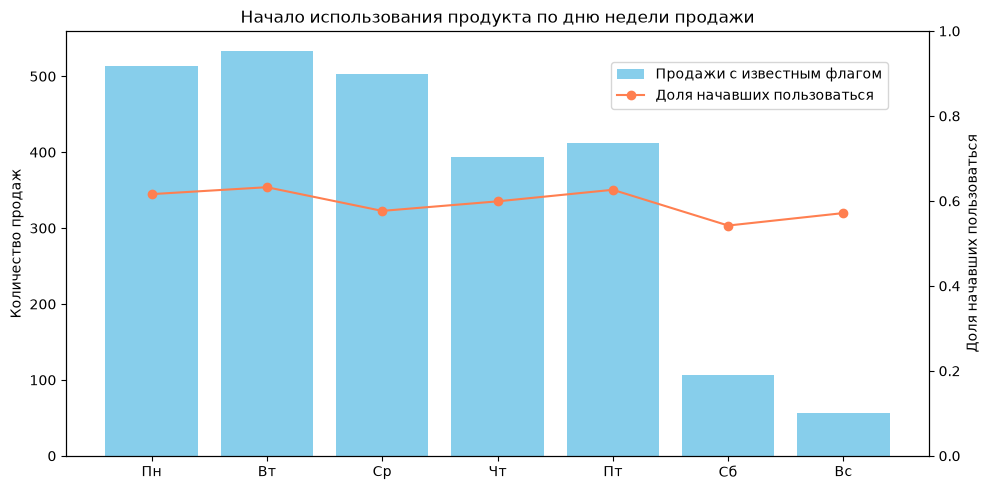

In [69]:
# Доля клиентов, начавших пользоваться продуктом, по дню недели продажи. Абсолютные количества
# по дням повторяют объём звонков (в выходные звонков мало), поэтому сравниваем доли
df = df_client_util_by_day.copy()
df['weekday'] = pd.to_datetime(df['day']).dt.dayofweek
by_weekday = df.groupby('weekday')[['sold_with_flag', 'usage_count']].sum()
by_weekday['usage_ratio'] = by_weekday['usage_count'] / by_weekday['sold_with_flag']
by_weekday.index = by_weekday.index.map(dict(enumerate(['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'])))
print(by_weekday)

chi2, p_value, _, _ = chi2_contingency(
    np.column_stack([by_weekday['usage_count'], by_weekday['sold_with_flag'] - by_weekday['usage_count']]))
print(f"\nХи-квадрат: {chi2:.2f}, p-значение: {p_value:.4f}")

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(by_weekday.index, by_weekday['sold_with_flag'], color='skyblue', label='Продажи с известным флагом')
ax1.set_ylabel('Количество продаж')
ax2 = ax1.twinx()
ax2.plot(by_weekday.index, by_weekday['usage_ratio'], color='coral', marker='o', label='Доля начавших пользоваться')
ax2.set_ylabel('Доля начавших пользоваться')
ax2.set_ylim(0, 1)
plt.title('Начало использования продукта по дню недели продажи')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.88))
plt.tight_layout()
plt.show()

Абсолютные количества по дням повторяют объём звонков (в выходные звонков мало), поэтому сравниваем доли. Заметной разницы по дням недели нет: от 54% в субботу до 63% во вторник, и критерий хи-квадрат её не подтверждает (p = 0,37). Пятница — среди лучших дней (62,6%). Продаж в выходные мало (107 в субботу и 56 в воскресенье), поэтому доли для них менее надёжны.

## Очереди

Посмотрим, сколько в среднем проходит от создания задачи до звонка по ней в каждой очереди. Это не время ожидания на линии: момента постановки звонка в очередь в базе нет.

In [70]:
# Время от создания задачи до окончания звонка по ней, в днях. Это не ожидание на линии:
# момента постановки звонка в очередь в базе нет
df_queue = q("""
SELECT q.queue_id, q.queue_desc,
       ROUND(AVG(
           STRFTIME('%s', c.finish_dttm) - STRFTIME('%s', t.create_dttm)
       ) / 86400.0, 1) AS avg_days_task_to_call,
       COUNT(DISTINCT c.wo_task_rk) AS task_count
FROM queue q
LEFT JOIN call c ON q.queue_id = c.wo_queue_id
LEFT JOIN task t ON c.wo_task_rk = t.task_rk
GROUP BY q.queue_id, q.queue_desc
HAVING COUNT(DISTINCT c.wo_task_rk) > 30  -- только очереди, в которых больше 30 задач
ORDER BY avg_days_task_to_call DESC
""")
df_queue

,queue_id,queue_desc,avg_days_task_to_call,task_count
0,13137,Очередь 2,32.4,89
1,9450,Очередь 107,30.1,71
2,4874,Очередь 76,19.0,112
3,12728,Очередь 63,18.6,398
4,12049,Очередь 86,17.1,216
5,2221,Очередь 33,16.0,342
6,14790,Очередь 23,15.8,1936
7,14354,Очередь 58,14.3,1825
8,15085,Очередь 75,13.6,681
9,4875,Очередь 5,13.5,192


Отобрал очереди, в которых больше 30 задач. В некоторых очередях от создания задачи до звонка в среднем проходит больше двух недель (например, «Очередь 2» — 32 дня, «Очередь 107» — 30 дней), в других — меньше суток. Если это не связано со спецификой очередей, в медленных очередях задачи стоит обрабатывать быстрее или выделить на них больше операторов.

## Задачи: этапы, даты создания и аномалии

In [71]:
q("""
SELECT task_stage_id, COUNT(*) AS stage_count
FROM task
GROUP BY task_stage_id
ORDER BY stage_count DESC
""")

,task_stage_id,stage_count
0,1.0,39173
1,23.0,7909
2,NaN,2366
3,17.0,218
4,6.0,175
5,3.0,105
6,18.0,38
7,4.0,12
8,16.0,3
9,20.0,1


Больше всего задач на этапах 1 (39 173) и 23 (7 909); у 2 366 задач этап не указан.

In [72]:
q("""
SELECT
  task_stage_id,
  AVG(julianday(finish_dttm) - julianday(create_dttm)) AS avg_duration_days
FROM
  task
GROUP BY
  task_stage_id
""")

,task_stage_id,avg_duration_days
0,NaN,4.243054
1,1.0,13.319906
2,3.0,NaN
3,4.0,NaN
4,6.0,1.509427
5,16.0,NaN
6,17.0,NaN
7,18.0,NaN
8,20.0,NaN
9,23.0,10.967098


Среднюю длительность удаётся посчитать только для этапов 1, 6, 23 и задач без этапа: у остальных этапов нет даты окончания.

In [73]:
q("""
SELECT
  COUNT(*) AS null_count
FROM
  task
WHERE
  task_stage_id IN (4, 16, 17, 18, 20, 3)
  AND finish_dttm IS NULL
""")

,null_count
0,377


In [74]:
df_null_task = q("""
SELECT
  task_stage_id, create_dttm, finish_dttm
FROM
  task
WHERE task_stage_id = 4 OR task_stage_id = 16 OR task_stage_id = 17 OR task_stage_id = 18 OR task_stage_id = 20 OR task_stage_id = 3
""")
df_null_task

,task_stage_id,create_dttm,finish_dttm
0,18.0,2022-08-25 09:05:53,None
1,3.0,2022-08-27 01:16:41,None
2,17.0,2022-08-10 16:50:47,None
3,3.0,2022-08-28 01:20:04,None
4,17.0,2022-08-01 13:55:14,None
5,17.0,2022-08-09 15:40:04,None
6,18.0,2022-08-26 09:32:07,None
7,3.0,2022-08-30 01:27:37,None
8,17.0,2022-08-31 16:40:50,None
9,4.0,2022-07-31 12:35:00,None


У всех задач на этапах 3, 4, 16, 17, 18 и 20 (377 задач) и у 173 из 175 задач этапа 6 нет даты окончания, а у этапов 1 и 23 она заполнена всегда. Скорее всего, это незавершённые, промежуточные этапы, а не сбой. Если же задачи на этих этапах на самом деле закрыты, стоит проверить выгрузку.

Изучим количество различных задач по дням.

In [75]:
df_task_by_days = q("""
SELECT DATE(create_dttm) AS task_date, task_stage_id, COUNT(*) AS task_count FROM task WHERE task_stage_id IN ( 6, 4, 16, 17, 18, 20, 3) GROUP BY task_date, task_stage_id ORDER BY task_date, task_stage_id
""")
df_task_by_days

,task_date,task_stage_id,task_count
0,2021-03-07,4.0,1
1,2021-04-08,4.0,1
2,2021-11-02,6.0,1
3,2021-11-24,4.0,1
4,2022-03-20,4.0,1
5,2022-03-24,6.0,1
6,2022-03-29,6.0,1
7,2022-03-30,6.0,1
8,2022-04-10,4.0,1
9,2022-04-25,6.0,1


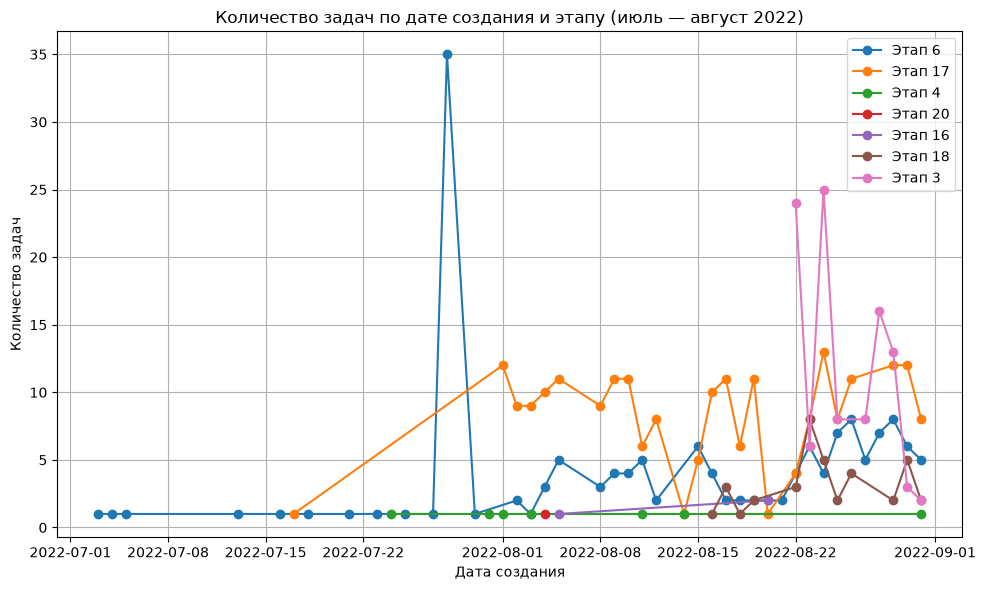

In [76]:
df = df_task_by_days.copy()
unique_task_stage_ids = df['task_stage_id'].unique()
df['task_date'] = pd.to_datetime(df['task_date'])


start_date = '2022-07-01'
end_date = '2022-09-30'

filtered_df = df[(df['task_date'] >= start_date) & (df['task_date'] <= end_date)]
unique_task_stage_ids = filtered_df['task_stage_id'].unique()
plt.figure(figsize=(10, 6))

for task_stage_id in unique_task_stage_ids:
    filtered_stage_df = filtered_df[filtered_df['task_stage_id'] == task_stage_id].copy()
    plt.plot(filtered_stage_df['task_date'], filtered_stage_df['task_count'], marker='o', label=f'Этап {task_stage_id:.0f}')


plt.title('Количество задач по дате создания и этапу (июль — август 2022)')
plt.xlabel('Дата создания')
plt.ylabel('Количество задач')


plt.legend()


plt.grid(True)
plt.tight_layout()
plt.show()

28 июля создано 35 задач этапа 6, а в остальные дни — не больше 8. Это стоит уточнить у владельцев данных.

Резкий рост всех задач с конца июля — эффект того, как собрана выгрузка: звонки в базе только за август 2022, и каждая задача в базе связана хотя бы с одним звонком. Задачи, созданные задолго до августа, попадают в базу, только если по ним ещё звонили в августе, поэтому чем раньше дата создания, тем меньше задач.

In [77]:
df_task_by_days_1_23 = q("""
SELECT DATE(create_dttm) AS task_date, task_stage_id, COUNT(*) AS task_count FROM task WHERE task_stage_id IN (1, 23) GROUP BY task_date, task_stage_id ORDER BY task_date, task_stage_id
""")
df_task_by_days_1_23

,task_date,task_stage_id,task_count
0,2021-04-02,1.0,1
1,2021-05-28,1.0,1
2,2021-06-18,1.0,1
3,2021-08-03,1.0,2
4,2021-09-03,1.0,1
5,2021-09-06,1.0,1
6,2021-09-12,1.0,1
7,2021-10-09,1.0,1
8,2021-10-13,1.0,1
9,2021-11-19,1.0,1


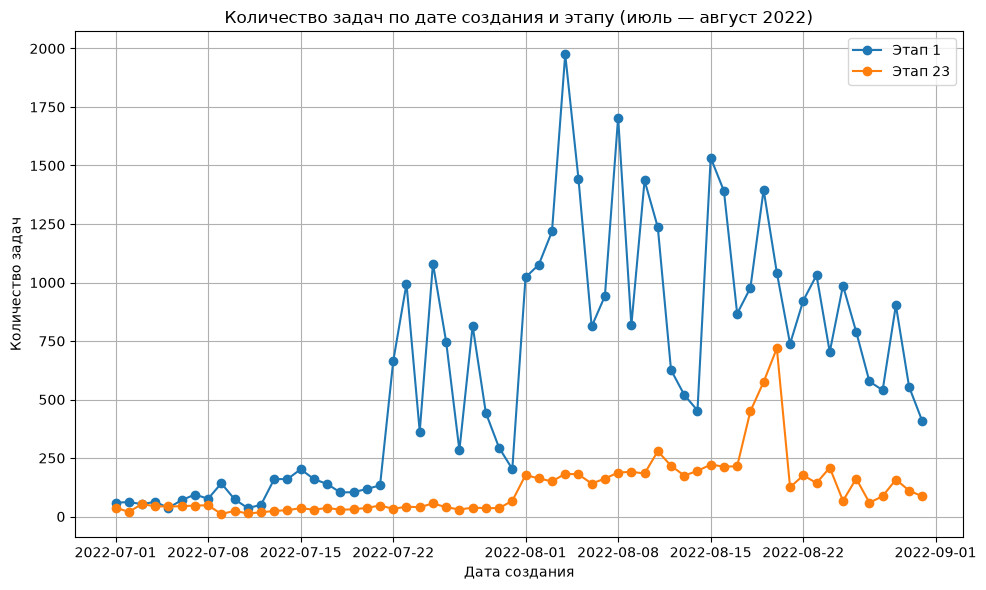

In [78]:
df = df_task_by_days_1_23.copy()
unique_task_stage_ids = df['task_stage_id'].unique()
df['task_date'] = pd.to_datetime(df['task_date'])


start_date = '2022-07-01'
end_date = '2022-09-30'

filtered_df = df[(df['task_date'] >= start_date) & (df['task_date'] <= end_date)]
unique_task_stage_ids = filtered_df['task_stage_id'].unique()
plt.figure(figsize=(10, 6))

for task_stage_id in unique_task_stage_ids:
    filtered_stage_df = filtered_df[filtered_df['task_stage_id'] == task_stage_id].copy()
    plt.plot(filtered_stage_df['task_date'], filtered_stage_df['task_count'], marker='o', label=f'Этап {task_stage_id:.0f}')


plt.title('Количество задач по дате создания и этапу (июль — август 2022)')
plt.xlabel('Дата создания')
plt.ylabel('Количество задач')


plt.legend()


plt.grid(True)
plt.tight_layout()
plt.show()

Для этапов 1 и 23 картина та же: рост с 22 июля — эффект выгрузки. Отдельно выделяется всплеск этапа 23 с 18 по 20 августа (450, 575 и 719 задач в день при обычных 100–250) — его тоже стоит уточнить.

In [79]:
# Даты хранятся текстом: разность finish_dttm - create_dttm в SQLite даёт разницу годов, поэтому считаем через julianday
df_task_duration = q("""
SELECT *, julianday(finish_dttm) - julianday(create_dttm) AS task_duration
FROM task
WHERE finish_dttm IS NOT NULL
""")

# Длительность сильно скошена вправо, поэтому «аномально долгие» — далёкие выбросы по правилу Тьюки: > Q3 + 3·IQR
q1, q3 = df_task_duration['task_duration'].quantile([0.25, 0.75])
duration_threshold = q3 + 3 * (q3 - q1)
df_time_duration_anomaly = (df_task_duration[df_task_duration['task_duration'] > duration_threshold]
                            .sort_values('task_duration', ascending=False))
print(f"Медиана: {df_task_duration['task_duration'].median():.1f} дн., порог: {duration_threshold:.1f} дн., "
      f"аномально долгих задач: {len(df_time_duration_anomaly)} из {len(df_task_duration)}")
print("Из них созданы до июля 2022:", (df_time_duration_anomaly['create_dttm'] < '2022-07-01').sum())
df_time_duration_anomaly

Медиана: 6.3 дн., порог: 62.1 дн., аномально долгих задач: 556 из 49450
Из них созданы до июля 2022: 183


,task_rk,task_stage_id,source_system_cd,create_dttm,finish_dttm,task_duration
216,65299911,1.0,GI,2021-04-02 10:25:39,2022-08-05 12:08:11,490.071204
14358,30098521,1.0,GI,2021-06-18 20:28:12,2022-09-20 12:07:07,458.652025
29704,78127149,1.0,GI,2021-05-28 12:43:36,2022-08-03 11:37:09,431.953854
39678,54729630,1.0,GI,2021-08-03 15:19:04,2022-09-20 12:07:22,412.866875
38046,27799374,1.0,GI,2021-09-03 10:01:28,2022-10-02 10:05:48,394.003009
19640,28389188,1.0,GI,2021-10-13 21:17:59,2022-10-14 10:24:49,365.546412
41223,56520375,1.0,GI,2021-08-03 04:43:36,2022-08-01 16:33:44,363.493148
26760,36621897,1.0,GI,2021-09-06 13:41:01,2022-08-09 15:35:10,337.079271
15882,51080931,1.0,GI,2021-09-12 05:14:42,2022-08-09 15:28:27,331.426215
19586,45976214,1.0,GI,2021-11-19 19:27:30,2022-10-12 02:00:00,326.272569


Медианная задача закрывается за 6 дней, но распределение длительности сильно скошено вправо. Аномально долгими считаем задачи дольше Q3 + 3·IQR (62 дня): таких 556 из 49 450 задач с датой окончания, 183 из них созданы ещё до июля 2022, самая долгая — в апреле 2021.

Вычитать даты напрямую (`finish_dttm - create_dttm`) нельзя: SQLite превращает текстовую дату в число по году, и такой запрос отбирает задачи, у которых год создания и год окончания различаются. Старые задачи попали в выгрузку потому, что по ним звонили в августе. Либо это аномалия, либо специфика задания позволяет выполнять его долго.

In [80]:
df_CM_anomaly = q("""
SELECT *
FROM task
WHERE task_stage_id IS NULL
""")
df_CM_anomaly

,task_rk,task_stage_id,source_system_cd,create_dttm,finish_dttm
0,15924764,None,CM,2022-08-25 13:02:45,2022-08-26 12:18:14
1,16344820,None,CM,2022-08-26 15:04:52,2022-09-06 16:22:02
2,92549484,None,CM,2022-07-31 05:15:27,2022-08-03 12:17:36
3,22342,None,CM,2022-08-08 18:10:26,2022-08-10 14:49:36
4,98815064,None,CM,2022-08-07 18:34:17,2022-08-15 11:57:03
5,94707726,None,CM,2022-08-02 06:45:24,2022-08-03 16:32:04
6,5465159,None,CM,2022-08-14 05:07:18,2022-08-16 12:50:49
7,7012177,None,CM,2022-08-16 12:05:01,2022-08-22 10:52:56
8,95245469,None,CM,2022-08-03 16:45:16,2022-08-04 08:56:02
9,14849597,None,CM,2022-08-24 05:11:32,2022-09-30 14:03:14


In [81]:
q("""
SELECT *
FROM task
WHERE task_stage_id IS NULL AND source_system_cd= 'CM'
""")

,task_rk,task_stage_id,source_system_cd,create_dttm,finish_dttm
0,15924764,None,CM,2022-08-25 13:02:45,2022-08-26 12:18:14
1,16344820,None,CM,2022-08-26 15:04:52,2022-09-06 16:22:02
2,92549484,None,CM,2022-07-31 05:15:27,2022-08-03 12:17:36
3,22342,None,CM,2022-08-08 18:10:26,2022-08-10 14:49:36
4,98815064,None,CM,2022-08-07 18:34:17,2022-08-15 11:57:03
5,94707726,None,CM,2022-08-02 06:45:24,2022-08-03 16:32:04
6,5465159,None,CM,2022-08-14 05:07:18,2022-08-16 12:50:49
7,7012177,None,CM,2022-08-16 12:05:01,2022-08-22 10:52:56
8,95245469,None,CM,2022-08-03 16:45:16,2022-08-04 08:56:02
9,14849597,None,CM,2022-08-24 05:11:32,2022-09-30 14:03:14


Аномалия: у всех 2 366 задач из источника CM не заполнен этап (`task_stage_id`), и только у них. Похоже, система CM не передаёт этап задачи.

## Excel-дашборд

Ноутбук целиком собирает `db_analysys.xlsx`: лист «Дашборд» с ключевыми показателями, выводами и графиками, листы «Аномалии» и «Регрессия», данные для графиков и детальные таблицы из разделов выше.

In [82]:
# Ключевые показатели — из витрины звонков
kpi = q("""
SELECT
    COUNT(*) AS calls,
    SUM(is_decided) AS decided,
    SUM(is_success) AS successes,
    SUM(is_success) * 1.0 / SUM(is_decided) AS conversion,
    SUM(is_reached) * 1.0 / SUM(is_reached OR status_desc = 'Недозвон') AS reach_rate,
    AVG(CASE WHEN is_success THEN using_flg END) AS usage_rate,
    AVG(CASE WHEN is_success THEN duration_sec END) AS avg_success_duration
FROM calls
""").iloc[0]

# Зона роста: сколько продаж в месяц добавится, если управления ниже средней конверсии
# (от 100 звонков с результатом) выйдут на среднюю
below_average = df_management[(df_management['Count_decided'] >= 100)
                              & (df_management['management_nm_ratio'] < kpi['conversion'])]
extra_sales = (kpi['conversion'] * below_average['Count_decided'] - below_average['Count_success']).sum()

print(kpi.round(4).to_string())
print(f"\nУправлений ниже средней: {len(below_average)}, дополнительных продаж в месяц: {extra_sales:.0f} "
      f"(+{extra_sales / kpi['successes']:.0%})")

calls                   89174.0000
decided                 21769.0000
successes                3310.0000
conversion                  0.1521
reach_rate                  0.4333
usage_rate                  0.6064
avg_success_duration      110.1754

Управлений ниже средней: 24, дополнительных продаж в месяц: 644 (+19%)


In [83]:
# Данные для графиков дашборда
df_mgmt_chart = (df_management[df_management['Count_decided'] >= 100]
                 .sort_values('management_nm_ratio', ascending=False)
                 .assign(management=lambda d: d['management_nm'].str.replace('Управление КЦ ', ''), average=kpi['conversion'])
                 [['management', 'Count_decided', 'Count_success', 'management_nm_ratio', 'average']])

df_hours = add_wilson_ci(q("""
SELECT CAST(hour_of_day AS INTEGER) AS hour, Count_Dialings AS decided, Successful_Calls AS successes,
       Sales_Conversion AS conversion
FROM Sales_Conversion_Per_Hour
"""), 'successes', 'decided')
df_hours = df_hours[df_hours['decided'] >= 30]  # часы с малым числом звонков на графике не показываем

df_days = df_days_sales_conversion.assign(day=lambda d: d['day'].dt.strftime('%d.%m')).rename(columns={
    'Count_Dialings': 'decided', 'Successful_Calls': 'successes', 'Sales_Conversions': 'conversion'})

df_products = add_wilson_ci(q("""
SELECT 'Продукт ' || product_hid AS product, SUM(is_decided) AS decided, SUM(is_success) AS successes,
       SUM(is_success) * 1.0 / SUM(is_decided) AS conversion
FROM calls
GROUP BY product_hid
ORDER BY product_hid
"""), 'successes', 'decided')

df_reach_chart = (df_reach.reset_index()[['Period', 'Reached', 'Total_Calls']]
                  .assign(reach_rate=lambda d: d['Reached'] / d['Total_Calls'],
                          Period=lambda d: d['Period'].map({'Weekday': 'Будни', 'Weekend': 'Выходные',
                                                            'Daytime (06-17)': 'День (06–17)',
                                                            'Nighttime (18-05)': 'Вечер и ночь (18–05)'})))

df_usage_weekday = by_weekday.reset_index(names='weekday')

# Отношения шансов для выходных и вечера во всех моделях
term_names = {'is_weekend': 'Выходные', 'is_night': 'Вечер (18:00–05:59)'}
df_regression = (pd.concat(time_results + [odds_ratios(within_model, ['is_weekend', 'is_night'])
                                           .assign(model='внутри одного оператора')])
                 .reset_index(names='term')
                 .assign(term=lambda d: d['term'].map(term_names))
                 [['model', 'term', 'odds_ratio', 'ci_low', 'ci_high', 'p_value']])
df_zodiac_or = (odds_ratios(zodiac_model, sign_terms)
                .rename(index=lambda t: t.split('[T.')[1].rstrip(']'))
                .sort_values('odds_ratio')
                .reset_index(names='horoscope'))

In [84]:
# Таблица аномалий
zero_success = q("""
SELECT agent_login, COUNT(*) AS calls FROM calls WHERE is_success AND duration_sec = 0 GROUP BY agent_login ORDER BY calls DESC
""")
flags = q("""
SELECT SUM(NOT is_success AND using_flg IS NOT NULL) AS flag_without_sale, SUM(is_success AND using_flg IS NULL) AS sale_without_flag
FROM calls
""").iloc[0]
stage_6 = df_task_by_days[df_task_by_days['task_stage_id'] == 6].set_index('task_date')['task_count']
stage_23 = df_task_by_days_1_23[(df_task_by_days_1_23['task_stage_id'] == 23)
                                & (df_task_by_days_1_23['task_date'] >= '2022-08-01')].set_index('task_date')['task_count']
virgo = df_horoscope.set_index('horoscope').loc['Дева', 'count_horoscope_agent']

df_anomalies = pd.DataFrame([
    ('«Успешные» звонки нулевой длительности', zero_success['calls'].sum(),
     f"все у операторов {', '.join(zero_success['agent_login'])}, которые возглавляют рейтинги; проверить отметку результата"),
    ('Управление Вирс: все звонки — «Недозвон»', len(df_virs), 'ни одного разговора за месяц; проверить очередь и номера'),
    ('Управление Вазан: звонков за месяц', len(df_vazan), 'новое управление или звонки не попали в базу'),
    ('Задачи источника CM без этапа', len(df_CM_anomaly), 'этап не заполнен у всех задач CM и только у них'),
    ('Задачи на этапах 3, 4, 16, 17, 18, 20 без даты окончания', len(df_null_task), 'скорее всего, незавершённые этапы'),
    (f'Задачи дольше {duration_threshold:.0f} дней', len(df_time_duration_anomaly),
     f"при медиане {df_task_duration['task_duration'].median():.0f} дней; самые старые созданы в 2021 году"),
    (f'Всплеск задач этапа 6 ({pd.to_datetime(stage_6.idxmax()):%d.%m})', stage_6.max(),
     f'в остальные дни — не больше {stage_6.drop(stage_6.idxmax()).max()}'),
    (f'Всплеск задач этапа 23 ({pd.to_datetime(stage_23.idxmax()):%d.%m}), задач в день', stage_23.max(),
     f'обычно {stage_23.quantile(0.25):.0f}–{stage_23.quantile(0.75):.0f} задач в день'),
    ('Флаг использования продукта у звонков без продажи', flags['flag_without_sale'], 'флаг должен быть только у продаж'),
    ('Продажи без флага использования', flags['sale_without_flag'], 'неизвестно, начал ли клиент пользоваться продуктом'),
    ('Операторы-«Девы» в справочнике знаков зодиака', virgo,
     f'{virgo / df_horoscope["count_horoscope_agent"].sum():.0%} операторов при ожидаемых около 8%; похоже на значения по умолчанию'),
], columns=['Аномалия', 'Количество', 'Комментарий'])
df_anomalies

,Аномалия,Количество,Комментарий
0,«Успешные» звонки нулевой длительности,58,"все у операторов cyanrser, yrovibna, которые в..."
1,Управление Вирс: все звонки — «Недозвон»,251,ни одного разговора за месяц; проверить очеред...
2,Управление Вазан: звонков за месяц,3,новое управление или звонки не попали в базу
3,Задачи источника CM без этапа,2366,этап не заполнен у всех задач CM и только у них
4,"Задачи на этапах 3, 4, 16, 17, 18, 20 без даты...",377,"скорее всего, незавершённые этапы"
5,Задачи дольше 62 дней,556,при медиане 6 дней; самые старые созданы в 202...
6,Всплеск задач этапа 6 (28.07),35,в остальные дни — не больше 8
7,"Всплеск задач этапа 23 (20.08), задач в день",719,обычно 146–211 задач в день
8,Флаг использования продукта у звонков без продажи,7,флаг должен быть только у продаж
9,Продажи без флага использования,792,"неизвестно, начал ли клиент пользоваться проду..."


In [85]:
def num(x):
    """Целое число с пробелом между разрядами: 3 310."""
    return f'{x:,.0f}'.replace(',', ' ')


def pct(x, digits=1):
    """Доля в процентах с запятой: 15,2%."""
    return f'{x:.{digits}%}'.replace('.', ',')


key_findings = [
    f"Продажная конверсия — {pct(kpi['conversion'])}: {num(kpi['successes'])} продаж из {num(kpi['decided'])} звонков "
    f"с результатом «Успешно» или «Отказ». Дозвон — {pct(kpi['reach_rate'])}, продуктом начинают пользоваться "
    f"{pct(kpi['usage_rate'], 0)} купивших.",
    f"Главная зона роста — управления. Хирс и группа 17 Керса продают в 65–69% случаев, а {len(below_average)} управлений "
    f"ниже средней. Если они выйдут на среднюю конверсию, это +{num(extra_sales)} продаж в месяц "
    f"(+{pct(extra_sales / kpi['successes'], 0)}).",
    "Вечером и в выходные конверсия выше, но за счёт того, кто в это время работает: у одного и того же оператора "
    "разница незначима. Переносить звонки на вечер не стоит — стоит изучить этих операторов.",
    "Продукт 2 продаётся хуже остальных: с учётом управления и времени шансы его продать на 38% ниже, чем продукт 1.",
    "Длительность звонка, источник задачи и знак зодиака оператора на результат не влияют "
    "(кроме необъяснимо низкой конверсии «Тельцов»).",
    "Аномалии в данных — на листе «Аномалии»: «успешные» звонки нулевой длительности у лидеров рейтинга, "
    "управление Вирс без единого разговора, задачи CM без этапа.",
]

with pd.ExcelWriter(DASHBOARD_PATH, engine='xlsxwriter') as writer:
    wb = writer.book
    fmt = {
        'title': wb.add_format({'bold': True, 'font_size': 18}),
        'note': wb.add_format({'font_color': '#595959'}),
        'h2': wb.add_format({'bold': True, 'font_size': 13}),
        'kpi_label': wb.add_format({'font_color': '#595959', 'bg_color': '#F2F2F2', 'text_wrap': True,
                                    'valign': 'vcenter', 'align': 'center'}),
        'kpi_int': wb.add_format({'bold': True, 'font_size': 16, 'num_format': '#,##0', 'bg_color': '#F2F2F2', 'align': 'center'}),
        'kpi_plus': wb.add_format({'bold': True, 'font_size': 16, 'num_format': '+#,##0', 'bg_color': '#E2EFDA', 'align': 'center'}),
        'kpi_pct': wb.add_format({'bold': True, 'font_size': 16, 'num_format': '0.0%', 'bg_color': '#F2F2F2', 'align': 'center'}),
        'kpi_sec': wb.add_format({'bold': True, 'font_size': 16, 'num_format': '0" с"', 'bg_color': '#F2F2F2', 'align': 'center'}),
        'finding': wb.add_format({'text_wrap': True, 'valign': 'top'}),
        'pct': wb.add_format({'num_format': '0.0%'}),
    }

    # Лист «Дашборд» создаётся первым, чтобы открываться первым
    dash = wb.add_worksheet('Дашборд')
    dash.hide_gridlines(2)
    dash.set_column('A:P', 11)
    dash.write('A1', 'Колл-центр банка: звонки за август 2022', fmt['title'])
    dash.write('A2', 'Файл собирается ноутбуком «Анализ_БД_звонков_банка.ipynb»; детальные таблицы — на следующих листах.',
               fmt['note'])

    kpi_tiles = [
        ('Звонков', kpi['calls'], 'kpi_int'),
        ('Звонков «Успешно» + «Отказ»', kpi['decided'], 'kpi_int'),
        ('Продаж', kpi['successes'], 'kpi_int'),
        ('Продажная конверсия', kpi['conversion'], 'kpi_pct'),
        ('Дозвон', kpi['reach_rate'], 'kpi_pct'),
        ('Начали пользоваться продуктом', kpi['usage_rate'], 'kpi_pct'),
        ('Средняя длительность продажи', kpi['avg_success_duration'], 'kpi_sec'),
        ('Продаж в месяц, если слабые управления выйдут на среднюю', extra_sales, 'kpi_plus'),
    ]
    dash.set_row(3, 45)
    dash.set_row(4, 30)
    for n, (label, value, style) in enumerate(kpi_tiles):
        dash.merge_range(3, 2 * n, 3, 2 * n + 1, label, fmt['kpi_label'])
        dash.merge_range(4, 2 * n, 4, 2 * n + 1, float(value), fmt[style])

    dash.write('A7', 'Главные выводы', fmt['h2'])
    for n, text in enumerate(key_findings):
        dash.set_row(7 + n, 32)
        dash.merge_range(7 + n, 0, 7 + n, 15, f'• {text}', fmt['finding'])

    # Данные графиков — на одном листе, блоками слева направо
    chart_sheet = 'Данные графиков'
    blocks, col = {}, 0
    for name, frame in [('management', df_mgmt_chart), ('hours', df_hours), ('days', df_days),
                        ('products', df_products), ('reach', df_reach_chart), ('usage', df_usage_weekday)]:
        frame.to_excel(writer, sheet_name=chart_sheet, startcol=col, index=False)
        blocks[name] = {'columns': {c: col + i for i, c in enumerate(frame.columns)}, 'rows': len(frame)}
        col += len(frame.columns) + 1
    writer.sheets[chart_sheet].autofit()

    def ref(block, column):
        """Диапазон значений столбца column из блока block на листе с данными графиков."""
        c = blocks[block]['columns'][column]
        return [chart_sheet, 1, c, blocks[block]['rows'], c]

    def ci_bars(frame, value='conversion'):
        """Планки 95% доверительного интервала для ряда value."""
        return {'type': 'custom', 'plus_values': (frame['ci_high'] - frame[value]).round(4).tolist(),
                'minus_values': (frame[value] - frame['ci_low']).round(4).tolist()}

    def combo_chart(block, title, categories, bars, line, bars_name, line_name, line_bars=None):
        """Столбцы с количеством звонков и линия конверсии на второй оси."""
        chart = wb.add_chart({'type': 'column'})
        chart.add_series({'name': bars_name, 'categories': ref(block, categories), 'values': ref(block, bars),
                          'fill': {'color': '#9DC3E6'}})
        line_chart = wb.add_chart({'type': 'line'})
        series = {'name': line_name, 'categories': ref(block, categories), 'values': ref(block, line),
                  'y2_axis': True, 'line': {'color': '#ED7D31'}, 'marker': {'type': 'circle'}}
        if line_bars:
            series['y_error_bars'] = line_bars
        line_chart.add_series(series)
        chart.combine(line_chart)
        chart.set_title({'name': title, 'name_font': {'size': 12}})
        line_chart.set_y2_axis({'num_format': '0%', 'name': 'Конверсия'})
        chart.set_y_axis({'name': bars_name})
        chart.set_legend({'position': 'bottom'})
        chart.set_size({'width': 560, 'height': 320})
        return chart

    dash.write('A15', 'Графики', fmt['h2'])

    chart = wb.add_chart({'type': 'column'})
    chart.add_series({'name': 'Конверсия', 'categories': ref('management', 'management'),
                      'values': ref('management', 'management_nm_ratio'), 'fill': {'color': '#4472C4'}})
    average_line = wb.add_chart({'type': 'line'})
    average_line.add_series({'name': f"Средняя ({pct(kpi['conversion'])})", 'categories': ref('management', 'management'),
                             'values': ref('management', 'average'), 'line': {'color': '#C00000', 'dash_type': 'dash'}})
    chart.combine(average_line)
    chart.set_title({'name': 'Продажная конверсия по управлениям (от 100 звонков с результатом)', 'name_font': {'size': 12}})
    chart.set_y_axis({'num_format': '0%'})
    chart.set_x_axis({'num_font': {'rotation': -45}})
    chart.set_legend({'position': 'bottom'})
    chart.set_size({'width': 1200, 'height': 380})
    dash.insert_chart('A16', chart)

    dash.insert_chart('A36', combo_chart('hours', 'Звонки и конверсия по часам (95% ДИ)', 'hour', 'decided', 'conversion',
                                         'Звонков с результатом', 'Конверсия', ci_bars(df_hours)))
    dash.insert_chart('H36', combo_chart('days', 'Звонки и конверсия по дням', 'day', 'decided', 'conversion',
                                         'Звонков с результатом', 'Конверсия'))

    chart = wb.add_chart({'type': 'column'})
    chart.add_series({'name': 'Конверсия', 'categories': ref('products', 'product'), 'values': ref('products', 'conversion'),
                      'fill': {'color': '#4472C4'}, 'y_error_bars': ci_bars(df_products),
                      'data_labels': {'value': True, 'num_format': '0.0%', 'position': 'center',
                                      'font': {'color': 'white', 'bold': True}}})
    chart.set_title({'name': 'Конверсия по продуктам (95% ДИ)', 'name_font': {'size': 12}})
    chart.set_y_axis({'num_format': '0%'})
    chart.set_legend({'none': True})
    chart.set_size({'width': 390, 'height': 300})
    dash.insert_chart('A53', chart)

    chart = wb.add_chart({'type': 'column'})
    chart.add_series({'name': 'Дозвон', 'categories': ref('reach', 'Period'), 'values': ref('reach', 'reach_rate'),
                      'fill': {'color': '#70AD47'}, 'data_labels': {'value': True, 'num_format': '0.0%', 'position': 'outside_end'}})
    chart.set_title({'name': 'Доля дозвона', 'name_font': {'size': 12}})
    chart.set_y_axis({'num_format': '0%', 'min': 0})
    chart.set_legend({'none': True})
    chart.set_size({'width': 390, 'height': 300})
    dash.insert_chart('F53', chart)

    chart = wb.add_chart({'type': 'column'})
    chart.add_series({'name': 'Начали пользоваться', 'categories': ref('usage', 'weekday'), 'values': ref('usage', 'usage_ratio'),
                      'fill': {'color': '#FFC000'}, 'data_labels': {'value': True, 'num_format': '0%', 'position': 'outside_end'}})
    chart.set_title({'name': 'Начали пользоваться продуктом, по дню продажи', 'name_font': {'size': 12}})
    chart.set_y_axis({'num_format': '0%', 'min': 0, 'max': 1})
    chart.set_legend({'none': True})
    chart.set_size({'width': 390, 'height': 300})
    dash.insert_chart('K53', chart)

    # Аномалии и регрессии
    df_anomalies.to_excel(writer, sheet_name='Аномалии', index=False)
    writer.sheets['Аномалии'].autofit()
    or_columns = {'odds_ratio': 'Отношение шансов', 'ci_low': '95% ДИ, от', 'ci_high': '95% ДИ, до', 'p_value': 'p'}
    df_regression.rename(columns={'model': 'Модель', 'term': 'Фактор', **or_columns}).to_excel(
        writer, sheet_name='Регрессия', index=False)
    df_zodiac_or.rename(columns={'horoscope': 'Знак зодиака', **or_columns}).to_excel(
        writer, sheet_name='Регрессия', index=False, startrow=len(df_regression) + 3)
    regression_sheet = writer.sheets['Регрессия']
    regression_sheet.autofit()  # до заголовка второй таблицы, чтобы он не раздувал первый столбец
    regression_sheet.write(len(df_regression) + 2, 0, 'Знак зодиака относительно «Девы» (с учётом группы, времени и продукта)',
                           fmt['h2'])

    # Детальные таблицы из разделов выше
    for sheet_name, frame in [
    ('horoscope', df_horoscope),
    ('agent_ratio', df_agent_ratio),
    ('agent_ratio_by_management', df_agent_ratio_by_management),
    ('management__group_nm', df_management_group_by_group_nm),
    ('group', df_group),
    ('management', df_management),
    ('vazan', df_vazan),
    ('virs', df_virs),
    ('result_for_hour', df_result_for_hour),
    ('days_sales_conversion', df_days_sales_conversion),
    ('queue', df_queue),
    ('null_task', df_null_task),
    ('task_by_days', df_task_by_days),
    ('task_by_days_1_23', df_task_by_days_1_23),
    ('client_util_by_day', df_client_util_by_day),
    ('time_duration_anomaly', df_time_duration_anomaly),
    ('CM_anomaly', df_CM_anomaly),
    ]:
        frame.to_excel(writer, sheet_name=sheet_name, index=False)
        writer.sheets[sheet_name].autofit()

print(f'Дашборд сохранён: {DASHBOARD_PATH}')

Дашборд сохранён: db_analysys.xlsx
